# EGT305 - Big Data Processing Platforms & Applications
## Assignment: Salary Prediction using PySpark ML

### Objective
- Perform data cleaning on PySpark
- Conduct Exploratory Data Analysis (EDA)
- Build ML models to predict salary
- Recommend career strategies for a mid-careerist

### Dataset
- **Employee_dataset.csv**: Job role, education, experience, industry, etc.
- **Employee_salaries.csv**: Salary in thousands (SGD)

---
## 1. Environment Setup & Imports

In [1]:
# Auto-detect environment and install dependencies
import sys
import os

def setup_environment():
    """Detect if running in Google Colab or local environment and setup accordingly."""
    is_colab = 'google.colab' in sys.modules
    
    # Fix PySpark Python version mismatch on Windows
    if not is_colab:
        os.environ["PYSPARK_PYTHON"] = sys.executable
        os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
        print(f"[INFO] PYSPARK_PYTHON set to: {sys.executable}")
    
    if is_colab:
        print("[INFO] Google Colab detected. Installing dependencies...")
        !apt-get install openjdk-11-jdk-headless -qq > /dev/null 2>&1
        !pip install pyspark pyarrow -q
        os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
        print("[INFO] Dependencies installed successfully.")
    else:
        print("[INFO] Local environment detected (VS Code / Jupyter).")
        # Check for required packages
        try:
            import pyarrow
            print(f"[INFO] pyArrow version: {pyarrow.__version__}")
        except ImportError:
            print("[ERROR] pyarrow not installed. Run: pip install pyarrow")
            raise
    
    return is_colab

IS_COLAB = setup_environment()
print(f"Environment: {'Google Colab' if IS_COLAB else 'Local'}")

[INFO] PYSPARK_PYTHON set to: /usr/bin/python3
[INFO] Local environment detected (VS Code / Jupyter).
[INFO] pyArrow version: 25.0.0
Environment: Local


In [2]:
# PySpark 4.x does not yet fully support pandas >= 3.0.0; suppress the FutureWarning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning,
                        message="PySpark does not yet fully support pandas")

# Core PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, avg, sum, min, max, stddev,
    when, desc, asc, round as spark_round,
    corr, upper, trim
)

# ML imports
from pyspark.ml.feature import (
    VectorAssembler, StringIndexer, OneHotEncoder
)
from pyspark.ml import Pipeline
from pyspark.ml.regression import (
    LinearRegression, RandomForestRegressor, GBTRegressor
)
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Matplotlib backend for pyspark.pandas plots
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

print("[INFO] All imports successful.")

[INFO] All imports successful.


In [3]:
# Chart styling helper - matches the styling used in the submitted report
# (blue = at/above median, red = below median, dashed line = computed median)
import matplotlib.pyplot as plt

BLUE = "#2E5E8C"
RED = "#C0392B"
GREEN = "#1F7A4D"

def salary_bar(pdf, xcol, ycol, title, xlabel, ylabel="Avg Salary ($K)",
               figsize=(9, 5), rot=35, median=None, color=BLUE):
    """Bar chart of avg salary; bars below `median` are colored red if median is given."""
    fig, ax = plt.subplots(figsize=figsize)
    if median is not None:
        colors = [BLUE if v >= median else RED for v in pdf[ycol]]
    else:
        colors = color
    ax.bar(pdf[xcol], pdf[ycol], color=colors)
    if median is not None:
        ax.axhline(median, color="crimson", linestyle="--", linewidth=1,
                    label=f"Median (${median:.0f}K)")
        ax.legend(fontsize=9, loc="upper right")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rot, ha="right")
    plt.tight_layout()
    plt.show()

print("[INFO] Chart styling helper loaded.")


[INFO] Chart styling helper loaded.


In [4]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("EGT305_SalaryPrediction") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "2g") \
    .config("spark.sql.repl.eagerEval", "true") \
    .getOrCreate()

# Suppress unnecessary Spark warnings
spark.sparkContext.setLogLevel("ERROR")

print(f"[INFO] Spark Session initialized. Version: {spark.version}")

[INFO] Spark Session initialized. Version: 4.2.0


---
## 2. Data Loading

In [5]:
# Define file paths
# Adjust paths based on environment
DATA_DIR = "./"  # Current directory
EMPLOYEE_FILE = os.path.join(DATA_DIR, "Employee_dataset.csv")
SALARY_FILE = os.path.join(DATA_DIR, "Employee_salaries.csv")

# Check if files exist
if not os.path.exists(EMPLOYEE_FILE):
    print(f"[WARNING] {EMPLOYEE_FILE} not found. Please ensure the CSV files are in the correct directory.")
    print(f"[INFO] Current directory: {os.getcwd()}")
    print(f"[INFO] Files in directory:")
    for f in os.listdir("."):
        if f.endswith(".csv"):
            print(f"  - {f}")
else:
    print(f"[INFO] Found: {EMPLOYEE_FILE}")
    print(f"[INFO] Found: {SALARY_FILE}")

[INFO] Found: ./Employee_dataset.csv
[INFO] Found: ./Employee_salaries.csv


In [6]:
# Load Employee Dataset
employee_df = spark.read.csv(EMPLOYEE_FILE, header=True, inferSchema=True)

# Load Salary Dataset
salary_df = spark.read.csv(SALARY_FILE, header=True, inferSchema=True)

print("[INFO] Datasets loaded successfully.")
print(f"\nEmployee Dataset Shape: ({employee_df.count():,}, {len(employee_df.columns)})")
print(f"Salary Dataset Shape: ({salary_df.count():,}, {len(salary_df.columns)})")

[INFO] Datasets loaded successfully.

Employee Dataset Shape: (1,000,000, 8)
Salary Dataset Shape: (1,000,000, 2)


In [7]:
# Display schema and sample data
print("=" * 60)
print("EMPLOYEE DATASET SCHEMA")
print("=" * 60)
employee_df.printSchema()

print("\n" + "=" * 60)
print("EMPLOYEE DATASET - FIRST 5 ROWS")
print("=" * 60)
employee_df.show(5, truncate=False)

EMPLOYEE DATASET SCHEMA
root
 |-- jobId: string (nullable = true)
 |-- companyId: string (nullable = true)
 |-- jobRole: string (nullable = true)
 |-- education: string (nullable = true)
 |-- major: string (nullable = true)
 |-- industry: string (nullable = true)
 |-- yearsExperience: integer (nullable = true)
 |-- distanceFromCBD: integer (nullable = true)


EMPLOYEE DATASET - FIRST 5 ROWS
+----------------+---------+-------+-----------+-----+--------+---------------+---------------+
|jobId           |companyId|jobRole|education  |major|industry|yearsExperience|distanceFromCBD|
+----------------+---------+-------+-----------+-----+--------+---------------+---------------+
|JOB1362684407687|COMP37   |CFO    |MASTERS    |MATH |HEALTH  |10             |83             |
|JOB1362684407688|COMP19   |CEO    |HIGH_SCHOOL|NONE |WEB     |3              |73             |
|NULL            |NULL     |NULL   |NULL       |NULL |NULL    |NULL           |NULL           |
|NULL            |NULL     |NU

In [8]:
print("=" * 60)
print("SALARY DATASET SCHEMA")
print("=" * 60)
salary_df.printSchema()

print("\n" + "=" * 60)
print("SALARY DATASET - FIRST 5 ROWS")
print("=" * 60)
salary_df.show(5, truncate=False)

SALARY DATASET SCHEMA
root
 |-- jobId: string (nullable = true)
 |-- salaryInThousands: integer (nullable = true)


SALARY DATASET - FIRST 5 ROWS
+----------------+-----------------+
|jobId           |salaryInThousands|
+----------------+-----------------+
|JOB1362684407687|130              |
|JOB1362684407688|101              |
|JOB1362684407689|137              |
|JOB1362684407690|142              |
|JOB1362684407691|163              |
+----------------+-----------------+
only showing top 5 rows


In [9]:
# Summary statistics for numeric columns
print("=" * 60)
print("EMPLOYEE DATASET - DESCRIPTIVE STATISTICS")
print("=" * 60)
employee_df.describe().show()

print("\n" + "=" * 60)
print("SALARY DATASET - DESCRIPTIVE STATISTICS")
print("=" * 60)
salary_df.describe().show()

EMPLOYEE DATASET - DESCRIPTIVE STATISTICS
+-------+----------------+---------+--------------+---------+-------+--------+-----------------+------------------+
|summary|           jobId|companyId|       jobRole|education|  major|industry|  yearsExperience|   distanceFromCBD|
+-------+----------------+---------+--------------+---------+-------+--------+-----------------+------------------+
|  count|          999895|   999852|        999835|   999814| 999793|  999786|           999802|            999834|
|   mean|            NULL|     NULL|          NULL|     NULL|   NULL|    NULL|11.99242349985297|56.876695531458225|
| stddev|            NULL|     NULL|          NULL|     NULL|   NULL|    NULL|7.212395393960851| 6796.951073247891|
|    min|JOB1362684407687|    COMP0|           CEO|BACHELORS|BIOLOGY|    AUTO|                0|                 0|
|    max|JOB1362685407686|    COMP9|VICE_PRESIDENT|     NONE|PHYSICS|     WEB|               24|           6777777|
+-------+----------------+----

---
## 3. Data Cleaning

**Rationale:** Raw data often contains duplicates, invalid entries, missing values, and outliers that can
bias downstream analysis and degrade ML model performance. Each cleaning step below is justified by
the nature of the data and the requirements of supervised learning (we need clean, complete, and
representative features paired with valid salary labels).

**Cleaning steps (in order of execution):**
1. **Remove duplicate rows** - Eliminate repeated `jobId` entries to prevent over-representation bias.
2. **Filter invalid entries** - Remove rows with `jobRole = 'SCAMMER'` (fabricated/invalid records).
3. **Handle missing values** - Drop rows with nulls in critical identifier/key columns; impute remaining nulls using median (numeric) or sentinel labels (categorical).
4. **Fix unwanted outliers** - Apply the IQR method to remove implausible values in `distanceFromCBD`.
5. **Merge datasets** - Inner-join employee and salary data on `jobId`; remove salary outliers post-merge.

**Expected impact:** Each step reports before/after row counts so the cumulative effect on dataset
size is transparent and auditable.

In [10]:
# Helper function to display cleaning step results
def cleaning_step_report(df_before, df_after, step_name, details=""):
    """Print a formatted before/after report for a data cleaning step.

    Provides an audit trail for each cleaning operation by comparing row counts
    before and after the step, and calculating the percentage of rows removed.

    Args:
        df_before (DataFrame): PySpark DataFrame before the cleaning step.
        df_after (DataFrame): PySpark DataFrame after the cleaning step.
        step_name (str): Human-readable name of the cleaning step.
        details (str, optional): Additional context about the step (e.g., method
            used, threshold values). Defaults to empty string.

    Returns:
        DataFrame: The df_after DataFrame (for chaining in pipeline).
    """
    count_before = df_before.count()
    count_after = df_after.count()
    removed = count_before - count_after
    pct_removed = (removed / count_before * 100) if count_before > 0 else 0
    
    print("\n" + "=" * 60)
    print(f"CLEANING STEP: {step_name}")
    print("=" * 60)
    if details:
        print(f"Details: {details}")
        print("-" * 60)
    print(f"Rows BEFORE: {count_before:,}")
    print(f"Rows AFTER:  {count_after:,}")
    print(f"Removed:     {removed:,} ({pct_removed:.1f}%)")
    print("=" * 60)
    
    return df_after

In [11]:
# Create a working copy of the dataframe
df = employee_df

# Store original count for final summary
original_count = df.count()
print(f"Original dataset count: {original_count:,} rows")

Original dataset count: 1,000,000 rows


### 3.1 Remove Duplicate Observations

**Justification:** Each row should represent a unique job posting. The `jobId` column serves as the
primary key for this dataset (as defined in the schema). Duplicate `jobId` entries likely arise from
data collection or extraction errors. Retaining duplicates would:
- Over-represent certain observations, introducing sampling bias into the training set.
- Inflate row counts misleadingly during EDA.
- Cause data leakage if the same observation appears in both train and test splits.

**Decision:** Drop all rows where `jobId` is not unique, keeping the first occurrence.

In [12]:
# Check for duplicates based on jobId
total_rows = df.count()
unique_job_ids = df.select("jobId").distinct().count()
duplicates = total_rows - unique_job_ids

print(f"Total rows: {total_rows:,}")
print(f"Unique jobId values: {unique_job_ids:,}")
print(f"Duplicate rows: {duplicates:,}")

Total rows: 1,000,000
Unique jobId values: 999,896
Duplicate rows: 104


In [13]:
# Remove duplicates based on jobId
df_before = df
df = df.dropDuplicates(["jobId"])

# IMPORTANT: cache + materialize immediately. dropDuplicates() has no
# deterministic tie-break rule for *which* duplicate row survives, and
# without caching, every later .count()/.filter() action re-triggers this
# entire pipeline from the raw CSV, potentially re-choosing DIFFERENT
# surviving rows each time (this is what caused the SCAMMER-count mismatch
# between this section and the filter below, in the uncached version).
# Caching here freezes the result so every downstream cell reads the SAME
# deduplicated data.
df = df.cache()
df.count()  # force materialization now, not lazily later

cleaning_step_report(df_before, df, "Remove Duplicates", "Dropped duplicate jobId entries")


CLEANING STEP: Remove Duplicates
Details: Dropped duplicate jobId entries
------------------------------------------------------------
Rows BEFORE: 1,000,000
Rows AFTER:  999,896
Removed:     104 (0.0%)


DataFrame[jobId: string, companyId: string, jobRole: string, education: string, major: string, industry: string, yearsExperience: int, distanceFromCBD: int]

### 3.2 Filter Invalid Entries (SCAMMER)

**Justification:** The `jobRole` value `'SCAMMER'` does not correspond to any legitimate job title.
These entries are fabricated or injected records that:
- Do not represent real employee profiles and therefore carry no predictive signal.
- Would introduce noise into the feature space, degrading model generalisation.
- Could cause the one-hot encoder to create a spurious `jobRole_SCAMMER` dimension.

**Decision:** Remove all rows where `jobRole == 'SCAMMER'` before any further processing.

In [14]:
# Check for SCAMMER entries
scammer_count = df.filter(col("jobRole") == "SCAMMER").count()
print(f"SCAMMER entries found: {scammer_count}")

# Show SCAMMER entries
if scammer_count > 0:
    print("\nSCAMMER entries detail:")
    df.filter(col("jobRole") == "SCAMMER").show(truncate=False)

SCAMMER entries found: 4

SCAMMER entries detail:
+----------------+---------+-------+-----------+-----+--------+---------------+---------------+
|jobId           |companyId|jobRole|education  |major|industry|yearsExperience|distanceFromCBD|
+----------------+---------+-------+-----------+-----+--------+---------------+---------------+
|JOB1362684407929|COMP40   |SCAMMER|NONE       |NONE |SERVICE |14             |6777777        |
|JOB1362684408041|COMP7    |SCAMMER|NONE       |NONE |SERVICE |0              |44444          |
|JOB1362684828687|COMP16   |SCAMMER|HIGH_SCHOOL|NONE |SERVICE |12             |23232          |
|JOB1362684407697|COMP56   |SCAMMER|HIGH_SCHOOL|NONE |SERVICE |24             |30             |
+----------------+---------+-------+-----------+-----+--------+---------------+---------------+



In [15]:
# Also check for other invalid job roles
print("Unique job roles in dataset:")
df.select("jobRole").distinct().orderBy("jobRole").show(truncate=False)

Unique job roles in dataset:
+--------------+
|jobRole       |
+--------------+
|NULL          |
|CEO           |
|CFO           |
|CTO           |
|JANITOR       |
|JUNIOR        |
|MANAGER       |
|PRESIDENT     |
|SCAMMER       |
|SENIOR        |
|VICE_PRESIDENT|
+--------------+



In [16]:
# Filter out SCAMMER entries
# NOTE: col("jobRole") != "SCAMMER" alone would ALSO silently drop null-jobRole
# rows, because SQL three-valued logic makes NULL != "SCAMMER" evaluate to NULL,
# not True, so .filter() excludes those rows too. Null jobRole rows are meant to
# be handled explicitly (and documented) at the Handle Missing Data step below,
# not silently absorbed here -- so we keep nulls in play at this step.
df_before = df
df = df.filter((col("jobRole") != "SCAMMER") | col("jobRole").isNull())

cleaning_step_report(df_before, df, "Filter Invalid Entries", "Removed rows with jobRole = 'SCAMMER'")


CLEANING STEP: Filter Invalid Entries
Details: Removed rows with jobRole = 'SCAMMER'
------------------------------------------------------------
Rows BEFORE: 999,896
Rows AFTER:  999,892
Removed:     4 (0.0%)


DataFrame[jobId: string, companyId: string, jobRole: string, education: string, major: string, industry: string, yearsExperience: int, distanceFromCBD: int]

### 3.3 Fix Structural Errors

**Method:** check every categorical column for case inconsistency and leading/trailing whitespace, and validate `jobId`/`companyId` against their expected ID format, before assuming the raw data is analysis-ready.

**Why check even if nothing looks wrong:** structural errors (mixed case, stray whitespace, malformed IDs) silently create duplicate categories after one-hot encoding (e.g. `'Ceo'` and `'CEO'` would become two different features instead of one) or break joins on `jobId`. This step is a deliberate check, run before Handle Missing Data, so any structural issue found here doesn't get accidentally papered over as a 'missing value' or 'outlier' by a later step.

In [17]:
# Structural error check: case consistency, whitespace, ID format
print("=" * 60)
print("STRUCTURAL ERROR CHECK")
print("=" * 60)

structural_issues = 0
categorical_cols = ["jobRole", "education", "major", "industry"]

for c in categorical_cols:
    non_upper = df.filter(col(c).isNotNull() & (col(c) != upper(col(c)))).count()
    has_ws = df.filter(col(c).isNotNull() & (col(c) != trim(col(c)))).count()
    print(f"{c:12s}: {non_upper} case-inconsistent, {has_ws} with whitespace")
    structural_issues += non_upper + has_ws

# ID format validation: expected pattern is JOB<digits> / COMP<digits>
bad_job_ids = df.filter(~col("jobId").rlike("^JOB[0-9]+$")).count()
bad_company_ids = df.filter(~col("companyId").rlike("^COMP[0-9]+$")).count()
print(f"{'jobId':12s}: {bad_job_ids} malformed")
print(f"{'companyId':12s}: {bad_company_ids} malformed")
structural_issues += bad_job_ids + bad_company_ids

# Sanity range check: numeric columns should not be negative at this stage
neg_years = df.filter(col("yearsExperience") < 0).count()
neg_distance = df.filter(col("distanceFromCBD") < 0).count()
print(f"{'yearsExperience':12s}: {neg_years} negative values")
print(f"{'distanceFromCBD':12s}: {neg_distance} negative values")
structural_issues += neg_years + neg_distance

print(f"\nTotal structural issues found: {structural_issues}")
if structural_issues == 0:
    print("No structural errors detected -- categorical values are uniformly")
    print("formatted (consistent case, no stray whitespace), and jobId/companyId")
    print("pass ID-format validation. No corrective action needed at this step.")
else:
    print("Structural issues found above -- standardise case/whitespace and")
    print("re-validate before proceeding.")


STRUCTURAL ERROR CHECK
jobRole     : 0 case-inconsistent, 0 with whitespace
education   : 0 case-inconsistent, 0 with whitespace
major       : 0 case-inconsistent, 0 with whitespace
industry    : 0 case-inconsistent, 0 with whitespace
jobId       : 0 malformed
companyId   : 0 malformed
yearsExperience: 0 negative values
distanceFromCBD: 0 negative values

Total structural issues found: 0
No structural errors detected -- categorical values are uniformly
formatted (consistent case, no stray whitespace), and jobId/companyId
pass ID-format validation. No corrective action needed at this step.


### 3.4 Handle Missing Data

**Justification and strategy:**

| Column | Missing handling | Rationale |
|--------|-----------------|-----------|
| `jobId` | **Drop row** | Primary key — a null `jobId` means the row cannot be identified or joined. |
| `companyId` | **Drop row** | Needed for group-level analysis; imputing a company would fabricate associations. |
| `jobRole` | **Drop row** | Core categorical feature — imputing a role would inject a false label. |
| `education` | **Fill with `'UNKNOWN'`** | Preserves the row while flagging the missingness as a distinct category. |
| `major` | **Fill with `'NONE'`** | Consistent with existing `'NONE'` values already present in the dataset for employees without a declared major. |
| `industry` | **Fill with `'UNKNOWN'`** | Same rationale as `education`. |
| `yearsExperience` | **Fill with median** | Median is robust to skewness and outliers, unlike the mean. Preserves central tendency. |
| `distanceFromCBD` | **Fill with median** | Same rationale as `yearsExperience`. |

**Why median over mean:** The numeric columns may contain right-skewed distributions (e.g., a few
employees with very high experience or distance). The median is resistant to such outliers and
provides a more representative central value for imputation.

In [18]:
# Check for null values in each column
print("=" * 60)
print("NULL VALUE ANALYSIS - BEFORE CLEANING")
print("=" * 60)

null_counts = df.select(
    [count(when(col(c).isNull(), c)).alias(c) for c in df.columns]
)
null_counts.show(truncate=False)

# Calculate percentage of nulls per column
total_rows = df.count()
print(f"\nTotal rows: {total_rows:,}")
print("\nNull percentage per column:")
for c in df.columns:
    null_count = df.filter(col(c).isNull()).count()
    pct = (null_count / total_rows * 100) if total_rows > 0 else 0
    if null_count > 0:
        print(f"  {c}: {null_count:,} ({pct:.1f}%)")

NULL VALUE ANALYSIS - BEFORE CLEANING
+-----+---------+-------+---------+-----+--------+---------------+---------------+
|jobId|companyId|jobRole|education|major|industry|yearsExperience|distanceFromCBD|
+-----+---------+-------+---------+-----+--------+---------------+---------------+
|1    |45       |82     |106      |132  |145     |136            |109            |
+-----+---------+-------+---------+-----+--------+---------------+---------------+


Total rows: 999,892

Null percentage per column:
  jobId: 1 (0.0%)
  companyId: 45 (0.0%)
  jobRole: 82 (0.0%)
  education: 106 (0.0%)
  major: 132 (0.0%)
  industry: 145 (0.0%)
  yearsExperience: 136 (0.0%)
  distanceFromCBD: 109 (0.0%)


In [19]:
df_before = df

# Step 1: Drop rows with nulls in critical columns
critical_cols = ["jobId", "companyId", "jobRole"]
df = df.na.drop(subset=critical_cols)
print(f"After dropping nulls in critical columns: {df.count():,} rows")

# Step 2: Calculate medians for numeric columns
median_years = df.approxQuantile("yearsExperience", [0.5], 0.01)[0]
median_distance = df.approxQuantile("distanceFromCBD", [0.5], 0.01)[0]
print(f"\nMedian yearsExperience: {median_years}")
print(f"Median distanceFromCBD: {median_distance}")

# Step 3: Fill remaining nulls
fill_values = {
    "education": "UNKNOWN",
    "major": "NONE",
    "industry": "UNKNOWN",
    "yearsExperience": median_years,
    "distanceFromCBD": median_distance
}

df = df.fillna(fill_values)

cleaning_step_report(df_before, df, "Handle Missing Data",
    f"Dropped nulls in critical cols ({', '.join(critical_cols)}).\n"
    f"Filled numeric nulls with median.\n"
    f"Filled categorical nulls with 'UNKNOWN'/'NONE'.")

After dropping nulls in critical columns: 999,805 rows

Median yearsExperience: 12.0
Median distanceFromCBD: 49.0

CLEANING STEP: Handle Missing Data
Details: Dropped nulls in critical cols (jobId, companyId, jobRole).
Filled numeric nulls with median.
Filled categorical nulls with 'UNKNOWN'/'NONE'.
------------------------------------------------------------
Rows BEFORE: 999,892
Rows AFTER:  999,805
Removed:     87 (0.0%)


DataFrame[jobId: string, companyId: string, jobRole: string, education: string, major: string, industry: string, yearsExperience: int, distanceFromCBD: int]

In [20]:
# Verify no nulls remain
print("=" * 60)
print("NULL VALUE ANALYSIS - AFTER CLEANING")
print("=" * 60)

null_counts_after = df.select(
    [count(when(col(c).isNull(), c)).alias(c) for c in df.columns]
)
null_counts_after.show(truncate=False)

NULL VALUE ANALYSIS - AFTER CLEANING
+-----+---------+-------+---------+-----+--------+---------------+---------------+
|jobId|companyId|jobRole|education|major|industry|yearsExperience|distanceFromCBD|
+-----+---------+-------+---------+-----+--------+---------------+---------------+
|0    |0        |0      |0        |0    |0       |0              |0              |
+-----+---------+-------+---------+-----+--------+---------------+---------------+



### 3.5 Fix Unwanted Outliers

**Method: Interquartile Range (IQR) — Tukey's fences**

**Why IQR over Z-score:** The IQR method is non-parametric; it does not assume the data follows a
normal distribution. This is appropriate here because `distanceFromCBD` and `yearsExperience` may
exhibit skewed distributions where a Z-score approach (which assumes normality) would misclassify
valid observations as outliers.

**Why the 1.5×IQR threshold:** The 1.5 multiplier is the standard Tukey fence convention, marking
observations beyond Q1 − 1.5·IQR or Q3 + 1.5·IQR as mild outliers. This is a well-established
rule of thumb in exploratory data analysis.

**Why `distanceFromCBD` is targeted:** Physical distance from the CBD has a natural upper bound
(the dataset covers Singapore, ~50 km across). Values exceeding the IQR upper fence are likely
data entry errors. In contrast, `yearsExperience` is validated in a subsequent check and confirmed
to contain no outliers (range 0–24 years is realistic).

In [21]:
# Analyze outliers in distanceFromCBD using IQR method
print("=" * 60)
print("OUTLIER ANALYSIS: distanceFromCBD")
print("=" * 60)

# Calculate IQR
quantiles = df.approxQuantile("distanceFromCBD", [0.25, 0.75], 0.01)
Q1, Q3 = quantiles
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound:.1f}")
print(f"Upper bound: {upper_bound:.1f}")

# Count outliers
outliers = df.filter(
    (col("distanceFromCBD") < lower_bound) | 
    (col("distanceFromCBD") > upper_bound)
).count()
print(f"\nOutliers detected: {outliers}")

# Show extreme values
print("\nExtreme distanceFromCBD values:")
df.select("jobId", "distanceFromCBD").orderBy(desc("distanceFromCBD")).show(10)

OUTLIER ANALYSIS: distanceFromCBD
Q1: 25.0
Q3: 74.0
IQR: 49.0
Lower bound: -48.5
Upper bound: 147.5

Outliers detected: 4

Extreme distanceFromCBD values:
+----------------+---------------+
|           jobId|distanceFromCBD|
+----------------+---------------+
|JOB1362684828625|         500000|
|JOB1362685358867|            500|
|JOB1362684407930|            454|
|JOB1362684407917|            400|
|JOB1362684410428|             99|
|JOB1362684408829|             99|
|JOB1362684408444|             99|
|JOB1362684410646|             99|
|JOB1362684410717|             99|
|JOB1362684414928|             99|
+----------------+---------------+
only showing top 10 rows


In [22]:
# Remove outliers
df_before = df

df = df.filter(
    (col("distanceFromCBD") >= lower_bound) & 
    (col("distanceFromCBD") <= upper_bound)
)

cleaning_step_report(df_before, df, "Fix Outliers (distanceFromCBD)",
    f"Removed values outside IQR bounds [{lower_bound:.1f}, {upper_bound:.1f}] km")


CLEANING STEP: Fix Outliers (distanceFromCBD)
Details: Removed values outside IQR bounds [-48.5, 147.5] km
------------------------------------------------------------
Rows BEFORE: 999,805
Rows AFTER:  999,801
Removed:     4 (0.0%)


DataFrame[jobId: string, companyId: string, jobRole: string, education: string, major: string, industry: string, yearsExperience: int, distanceFromCBD: int]

In [23]:
# Also check for outliers in yearsExperience
print("=" * 60)
print("OUTLIER ANALYSIS: yearsExperience")
print("=" * 60)

quantiles_exp = df.approxQuantile("yearsExperience", [0.25, 0.75], 0.01)
Q1_exp, Q3_exp = quantiles_exp
IQR_exp = Q3_exp - Q1_exp

lower_exp = Q1_exp - 1.5 * IQR_exp
upper_exp = Q3_exp + 1.5 * IQR_exp

print(f"Q1: {Q1_exp}, Q3: {Q3_exp}, IQR: {IQR_exp}")
print(f"Bounds: [{lower_exp:.1f}, {upper_exp:.1f}]")

outliers_exp = df.filter(
    (col("yearsExperience") < lower_exp) | 
    (col("yearsExperience") > upper_exp)
).count()
print(f"Outliers detected: {outliers_exp}")

if outliers_exp > 0:
    print("\nThese are likely valid values (0-24 years range). Keeping them.")
else:
    print("No outliers detected in yearsExperience.")

OUTLIER ANALYSIS: yearsExperience
Q1: 6.0, Q3: 18.0, IQR: 12.0
Bounds: [-12.0, 36.0]
Outliers detected: 0
No outliers detected in yearsExperience.


### 3.6 Merge Datasets

**Join type: Inner join on `jobId`**

**Why inner join:** Supervised learning requires every training sample to have both features (from
the employee dataset) and a label (salary). An inner join ensures only rows with matched salary
records are retained. A left join would introduce unlabelled rows that cannot contribute to model
training and would need to be dropped anyway.

**Post-merge salary outlier removal:** After merging, salary values (`salaryInThousands`) are checked
for outliers using the same IQR method. This is done post-merge (rather than on the standalone
salary file) because:
- Salary is the **target variable** — extreme values disproportionately influence model loss
  functions (especially MSE-based losses in linear regression and GBT).
- We can only assess salary in the context of the full feature set (e.g., verifying that a very
  high salary corresponds to a CEO role, not a data entry error).

In [24]:
# Merge employee data with salary data on jobId
print("=" * 60)
print("DATASET MERGE")
print("=" * 60)

employee_count = df.count()
salary_count = salary_df.count()

print(f"Employee records: {employee_count:,}")
print(f"Salary records: {salary_count:,}")

# Perform inner join
merged_df = df.join(salary_df, on="jobId", how="inner")

merged_count = merged_df.count()
print(f"Merged records (inner join): {merged_count:,}")
print(f"\nNote: {employee_count - merged_count} employee records had no matching salary.")

DATASET MERGE
Employee records: 999,801
Salary records: 1,000,000
Merged records (inner join): 999,582

Note: 219 employee records had no matching salary.


In [25]:
# Handle nulls in salary column if any
salary_nulls = merged_df.filter(col("salaryInThousands").isNull()).count()
if salary_nulls > 0:
    print(f"Found {salary_nulls} rows with null salary. Removing them.")
    merged_df = merged_df.na.drop(subset=["salaryInThousands"])

print(f"\nAfter null removal: {merged_df.count():,} rows, {len(merged_df.columns)} columns")

Found 6 rows with null salary. Removing them.

After null removal: 999,576 rows, 9 columns


In [26]:
# Remove salary outliers using IQR method
print("=" * 60)
print("OUTLIER ANALYSIS: salaryInThousands")
print("=" * 60)

salary_before = merged_df.count()

quantiles_sal = merged_df.approxQuantile("salaryInThousands", [0.25, 0.75], 0.01)
Q1_sal, Q3_sal = quantiles_sal
IQR_sal = Q3_sal - Q1_sal

lower_sal = Q1_sal - 1.5 * IQR_sal
upper_sal = Q3_sal + 1.5 * IQR_sal

print(f"Q1: {Q1_sal:.2f}, Q3: {Q3_sal:.2f}, IQR: {IQR_sal:.2f}")
print(f"Bounds: [{lower_sal:.2f}, {upper_sal:.2f}] (thousands)")

salary_outliers = merged_df.filter(
    (col("salaryInThousands") < lower_sal) | 
    (col("salaryInThousands") > upper_sal)
).count()
print(f"Salary outliers detected: {salary_outliers:,}")

if salary_outliers > 0:
    print("\nExtreme salary values:")
    merged_df.select("jobId", "salaryInThousands").orderBy(desc("salaryInThousands")).show(5)
    print("Removing salary outliers...")
    merged_df = merged_df.filter(
        (col("salaryInThousands") >= lower_sal) & 
        (col("salaryInThousands") <= upper_sal)
    )

print(f"After salary outlier removal: {merged_df.count():,} rows")

OUTLIER ANALYSIS: salaryInThousands
Q1: 89.00, Q3: 141.00, IQR: 52.00
Bounds: [11.00, 219.00] (thousands)
Salary outliers detected: 7,579

Extreme salary values:
+----------------+-----------------+
|           jobId|salaryInThousands|
+----------------+-----------------+
|JOB1362685311220|         10000000|
|JOB1362684808298|              301|
|JOB1362685093249|              301|
|JOB1362684980464|              298|
|JOB1362685319434|              294|
+----------------+-----------------+
only showing top 5 rows
Removing salary outliers...
After salary outlier removal: 991,997 rows


In [27]:
# Cache the final cleaned dataset: it is read repeatedly across every EDA
# and ML cell from here on. Without caching, each of those actions would
# re-run the entire cleaning pipeline (dedup -> filter -> impute -> outliers
# -> merge) from the raw CSVs again, which is both wasteful and, per the
# note above, a reproducibility risk.
merged_df = merged_df.cache()

# Display cleaned and merged dataset
print("=" * 60)
print("CLEANED DATASET - FINAL SUMMARY")
print("=" * 60)

final_count = merged_df.count()
print(f"Original dataset: {original_count:,} rows")
print(f"Final cleaned dataset: {final_count:,} rows")
print(f"Total rows removed: {original_count - final_count:,} ({(original_count - final_count) / original_count * 100:.1f}%)")

print("\n" + "=" * 60)
print("FINAL SCHEMA")
print("=" * 60)
merged_df.printSchema()

merged_df.show(5, truncate=False)

CLEANED DATASET - FINAL SUMMARY
Original dataset: 1,000,000 rows
Final cleaned dataset: 991,997 rows
Total rows removed: 8,003 (0.8%)

FINAL SCHEMA
root
 |-- jobId: string (nullable = true)
 |-- companyId: string (nullable = true)
 |-- jobRole: string (nullable = true)
 |-- education: string (nullable = false)
 |-- major: string (nullable = false)
 |-- industry: string (nullable = false)
 |-- yearsExperience: integer (nullable = true)
 |-- distanceFromCBD: integer (nullable = true)
 |-- salaryInThousands: integer (nullable = true)

+----------------+---------+--------------+-----------+----------+--------+---------------+---------------+-----------------+
|jobId           |companyId|jobRole       |education  |major     |industry|yearsExperience|distanceFromCBD|salaryInThousands|
+----------------+---------+--------------+-----------+----------+--------+---------------+---------------+-----------------+
|JOB1362684407701|COMP57   |JANITOR       |NONE       |NONE      |AUTO    |21       

---
## 4. Exploratory Data Analysis (EDA)

In [28]:
# 4.1 Overall Salary Distribution
print("=" * 60)
print("SALARY DISTRIBUTION OVERVIEW")
print("=" * 60)

salary_stats = merged_df.select(
    count("salaryInThousands").alias("count"),
    spark_round(avg("salaryInThousands"), 2).alias("mean"),
    spark_round(stddev("salaryInThousands"), 2).alias("stddev"),
    min("salaryInThousands").alias("min"),
    max("salaryInThousands").alias("max")
)

salary_stats.show(truncate=False)

SALARY DISTRIBUTION OVERVIEW
+------+------+------+---+---+
|count |mean  |stddev|min|max|
+------+------+------+---+---+
|991997|115.16|37.46 |17 |219|
+------+------+------+---+---+



<Axes: title={'center': 'Salary Distribution'}, xlabel='Salary Range (SGD)', ylabel='Count'>

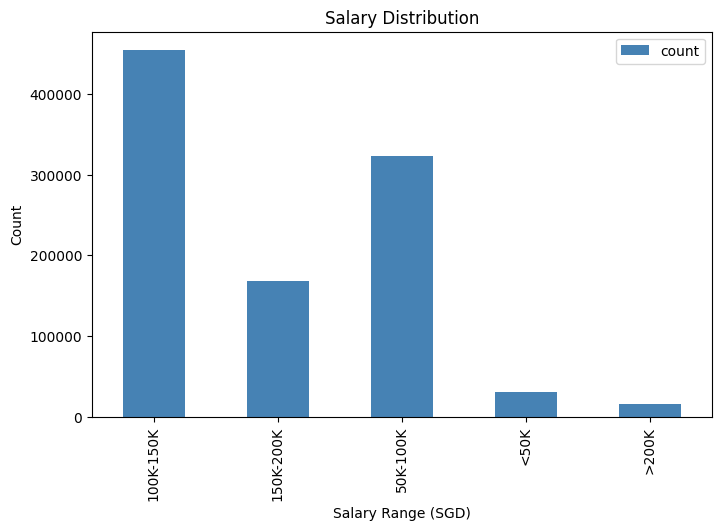

In [29]:
# Histogram: Salary Distribution
# Bin salaries into ranges for visualization
salary_binned = merged_df.select(
    col("salaryInThousands"),
    when(col("salaryInThousands") < 50, "<50K")
    .when(col("salaryInThousands") < 100, "50K-100K")
    .when(col("salaryInThousands") < 150, "100K-150K")
    .when(col("salaryInThousands") < 200, "150K-200K")
    .otherwise(">200K")
    .alias("salary_range")
)

salary_hist = salary_binned.groupBy("salary_range").count().orderBy("salary_range")

# Convert to pandas-on-Spark for plotting
ps_salary_hist = salary_hist.pandas_api()
ps_salary_hist.plot.bar(x="salary_range", y="count", backend="matplotlib", 
                         title="Salary Distribution",
                         xlabel="Salary Range (SGD)", 
                         ylabel="Count",
                         figsize=(8, 5),
                         color="steelblue")

In [30]:
# Compute median salary from dataset
# This median is used for below-median analyses in later EDA questions
median_salary = merged_df.approxQuantile("salaryInThousands", [0.5], 0.01)[0]

print("=" * 60)
print("DATASET MEDIAN SALARY")
print("=" * 60)
print(f"Median salary: ${median_salary:.0f}K (SGD thousands)")
print(f"\nNote: This is computed from the cleaned dataset, not assumed.")
print(f"All below-median analyses below use this value.")

DATASET MEDIAN SALARY
Median salary: $113K (SGD thousands)

Note: This is computed from the cleaned dataset, not assumed.
All below-median analyses below use this value.


TOP 10 JOB ROLES BY AVERAGE SALARY
+--------------+------+----------+----------+----------+
|jobRole       |count |avg_salary|min_salary|max_salary|
+--------------+------+----------+----------+----------+
|CEO           |121323|142.8     |55        |219       |
|CTO           |123414|134.23    |51        |219       |
|CFO           |122719|134.19    |51        |219       |
|VICE_PRESIDENT|124513|124.8     |44        |219       |
|MANAGER       |124831|115.15    |37        |219       |
|SENIOR        |125766|105.42    |31        |219       |
|JUNIOR        |124507|95.31     |23        |219       |
|PRESIDENT     |1     |81.0      |81        |81        |
|JANITOR       |124923|70.81     |17        |189       |
+--------------+------+----------+----------+----------+



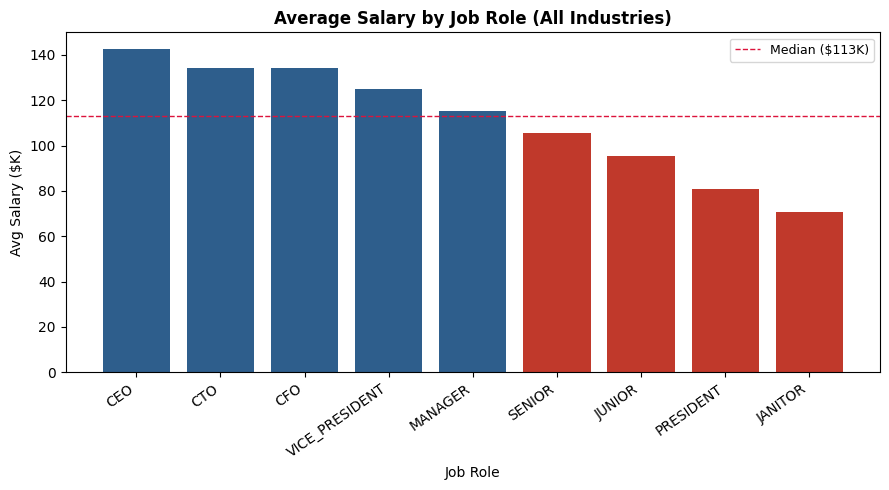

In [31]:
# Q2: Top 10 Job Roles by Average Salary (all industries)
print("=" * 60)
print("TOP 10 JOB ROLES BY AVERAGE SALARY")
print("=" * 60)

salary_by_role = merged_df.groupBy("jobRole") \
    .agg(
        count("salaryInThousands").alias("count"),
        spark_round(avg("salaryInThousands"), 2).alias("avg_salary"),
        spark_round(min("salaryInThousands"), 2).alias("min_salary"),
        spark_round(max("salaryInThousands"), 2).alias("max_salary")
    ) \
    .orderBy(desc("avg_salary"))

salary_by_role.show(10, truncate=False)

# Visualization - styled to match report (blue = at/above median, red = below median)
pdf_role = salary_by_role.limit(10).toPandas()
salary_bar(pdf_role, "jobRole", "avg_salary",
           title="Average Salary by Job Role (All Industries)",
           xlabel="Job Role", median=median_salary, figsize=(9, 5))

EXPERIENCE vs SALARY CORRELATION
Correlation coefficient: 0.3644
+---------------+----------+
|yearsExperience|avg_salary|
+---------------+----------+
|0              |91.87     |
|1              |93.96     |
|2              |96.12     |
|3              |98.08     |
|4              |99.99     |
|5              |101.63    |
|6              |103.87    |
|7              |105.97    |
|8              |107.71    |
|9              |109.99    |
|10             |111.99    |
|11             |113.65    |
|12             |116.01    |
|13             |117.48    |
|14             |119.77    |
|15             |121.25    |
|16             |123.33    |
|17             |125.11    |
|18             |127.16    |
|19             |128.67    |
|20             |130.32    |
|21             |132.02    |
|22             |133.87    |
|23             |135.57    |
|24             |136.94    |
+---------------+----------+



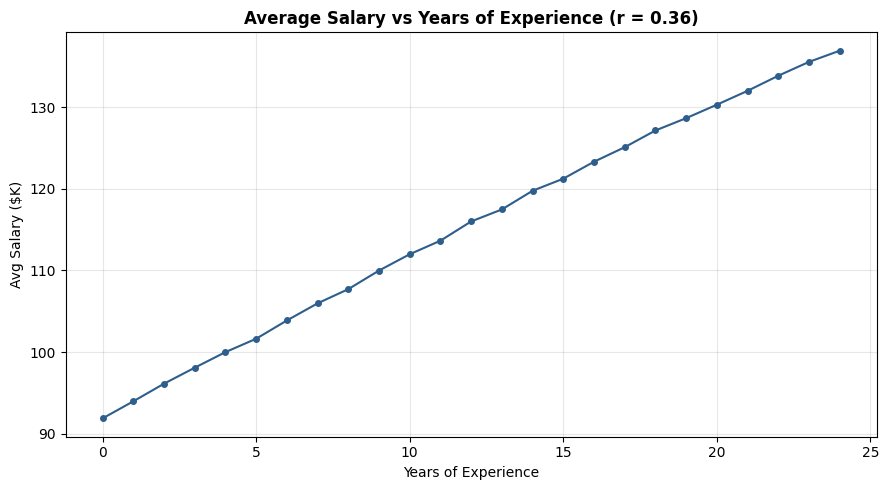

In [32]:
# 4.3 Years of Experience vs Salary
print("=" * 60)
print("EXPERIENCE vs SALARY CORRELATION")
print("=" * 60)

# Calculate correlation
corr_value = merged_df.select(corr("yearsExperience", "salaryInThousands")).collect()[0][0]
print(f"Correlation coefficient: {corr_value:.4f}")

# Average salary by years of experience
exp_salary = merged_df.groupBy("yearsExperience") \
    .agg(spark_round(avg("salaryInThousands"), 2).alias("avg_salary")) \
    .orderBy("yearsExperience")

exp_salary.show(25, truncate=False)

# Visualization - styled to match report
pdf_exp = exp_salary.toPandas()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pdf_exp["yearsExperience"], pdf_exp["avg_salary"], marker="o",
        markersize=4, color=BLUE, linewidth=1.5)
ax.set_title(f"Average Salary vs Years of Experience (r = {corr_value:.2f})",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Avg Salary ($K)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

SALARY BY EDUCATION LEVEL
+-----------+------+----------+
|education  |count |avg_salary|
+-----------+------+----------+
|DOCTORAL   |172124|133.67    |
|MASTERS    |172974|129.16    |
|BACHELORS  |173871|124.5     |
|UNKNOWN    |37    |105.92    |
|HIGH_SCHOOL|236493|101.71    |
|NONE       |236498|98.05     |
+-----------+------+----------+



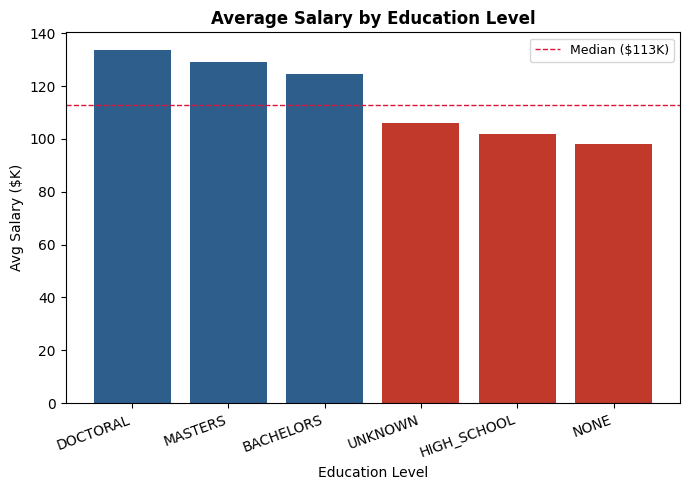

In [33]:
# 4.4 Salary by Education Level
print("=" * 60)
print("SALARY BY EDUCATION LEVEL")
print("=" * 60)

salary_by_edu = merged_df.groupBy("education") \
    .agg(
        count("salaryInThousands").alias("count"),
        spark_round(avg("salaryInThousands"), 2).alias("avg_salary")
    ) \
    .orderBy(desc("avg_salary"))

salary_by_edu.show(truncate=False)

# Visualization - styled to match report
pdf_edu = salary_by_edu.toPandas()
salary_bar(pdf_edu, "education", "avg_salary",
           title="Average Salary by Education Level",
           xlabel="Education Level", median=median_salary, rot=20, figsize=(7, 5))

SALARY BY INDUSTRY
+----------+------+----------+
|industry  |count |avg_salary|
+----------+------+----------+
|OIL       |140202|129.11    |
|FINANCE   |140455|129.02    |
|WEB       |141766|120.56    |
|HEALTH    |142001|115.19    |
|AUTO      |142516|109.13    |
|UNKNOWN   |100   |109.1     |
|SERVICE   |142341|104.26    |
|EDUCATION |142615|99.34     |
|GOVERNMENT|1     |81.0      |
+----------+------+----------+



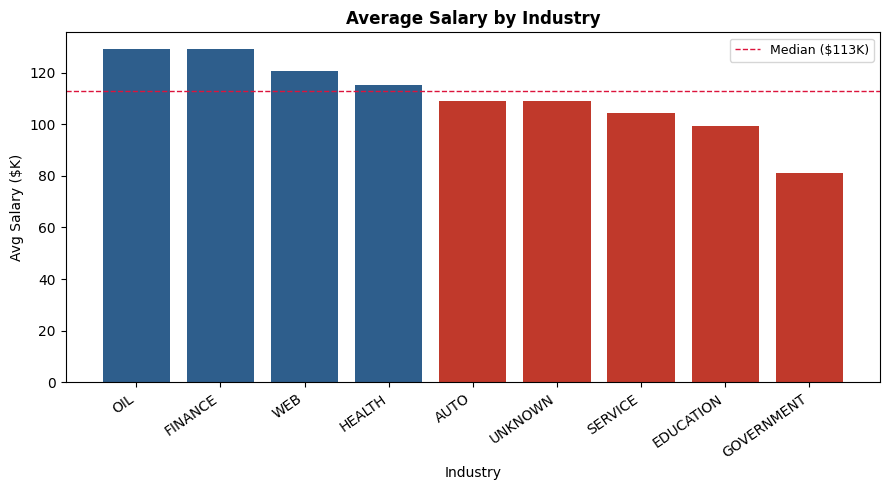

In [34]:
# 4.5 Salary by Industry
print("=" * 60)
print("SALARY BY INDUSTRY")
print("=" * 60)

salary_by_industry = merged_df.groupBy("industry") \
    .agg(
        count("salaryInThousands").alias("count"),
        spark_round(avg("salaryInThousands"), 2).alias("avg_salary")
    ) \
    .orderBy(desc("avg_salary"))

salary_by_industry.show(truncate=False)

# Visualization - styled to match report
pdf_ind = salary_by_industry.toPandas()
salary_bar(pdf_ind, "industry", "avg_salary",
           title="Average Salary by Industry",
           xlabel="Industry", median=median_salary, figsize=(9, 5))

Q1: HIGHEST PAYING JOB ROLE IN WEB INDUSTRY
+--------------+-----+----------+
|jobRole       |count|avg_salary|
+--------------+-----+----------+
|CEO           |17277|147.69    |
|CTO           |17580|140.06    |
|CFO           |17640|139.71    |
|VICE_PRESIDENT|17793|130.72    |
|MANAGER       |17773|120.73    |
|SENIOR        |17924|111.11    |
|JUNIOR        |17830|101.12    |
|JANITOR       |17949|75.04     |
+--------------+-----+----------+


Answer: The highest paying job role in the WEB industry is CEO with an average salary of $148K.


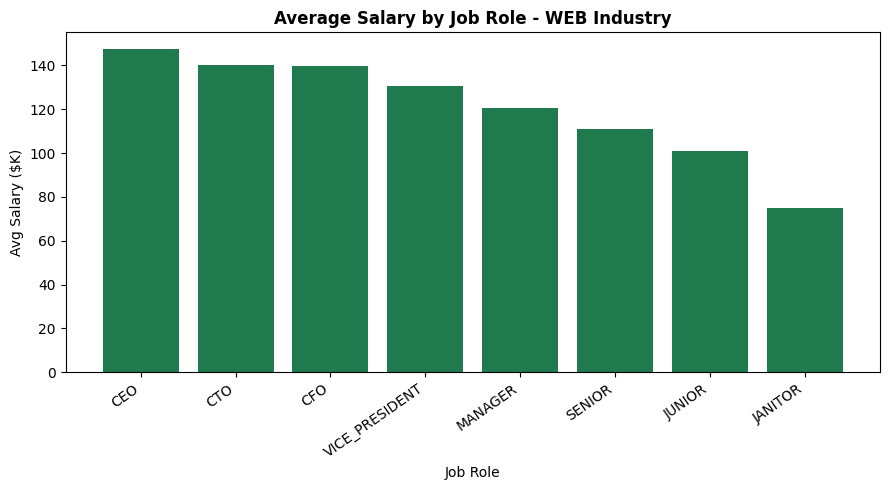

In [35]:
# Q1: Highest paying job role in the WEB industry
print("=" * 60)
print("Q1: HIGHEST PAYING JOB ROLE IN WEB INDUSTRY")
print("=" * 60)

web_roles = merged_df.filter(col("industry") == "WEB") \
    .groupBy("jobRole") \
    .agg(
        count("salaryInThousands").alias("count"),
        spark_round(avg("salaryInThousands"), 2).alias("avg_salary")
    ) \
    .orderBy(desc("avg_salary"))

web_roles.show(truncate=False)

top_web_role = web_roles.first()
print(f"\nAnswer: The highest paying job role in the WEB industry is "
      f"{top_web_role['jobRole']} with an average salary of ${top_web_role['avg_salary']:.0f}K.")

# Visualization - styled to match report (WEB industry only, no median line needed)
pdf_web = web_roles.toPandas()
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(pdf_web["jobRole"], pdf_web["avg_salary"], color=GREEN)
ax.set_title("Average Salary by Job Role - WEB Industry", fontsize=12, fontweight="bold")
ax.set_xlabel("Job Role")
ax.set_ylabel("Avg Salary ($K)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [36]:
# Q3: Which industry has the highest salary?
print("=" * 60)
print("Q3: INDUSTRY WITH HIGHEST SALARY")
print("=" * 60)

top_industry = salary_by_industry.first()
print(f"Answer: {top_industry['industry']} has the highest average salary "
      f"at ${top_industry['avg_salary']:.0f}K.")

# Q4: Which job has the lowest pay?
print("\n" + "=" * 60)
print("Q4: JOB WITH LOWEST PAY")
print("=" * 60)

lowest_role = salary_by_role.orderBy(asc("avg_salary")).first()
print(f"Answer: {lowest_role['jobRole']} has the lowest average salary "
      f"at ${lowest_role['avg_salary']:.0f}K.")

# Q5: Which industries have the lowest pay?
print("\n" + "=" * 60)
print("Q5: INDUSTRIES WITH LOWEST PAY")
print("=" * 60)

lowest_industries = salary_by_industry.orderBy(asc("avg_salary")).show(truncate=False)

bottom_ind = salary_by_industry.orderBy(asc("avg_salary")).first()
print(f"Answer: {bottom_ind['industry']} has the lowest average salary "
      f"at ${bottom_ind['avg_salary']:.0f}K.")

Q3: INDUSTRY WITH HIGHEST SALARY
Answer: OIL has the highest average salary at $129K.

Q4: JOB WITH LOWEST PAY
Answer: JANITOR has the lowest average salary at $71K.

Q5: INDUSTRIES WITH LOWEST PAY
+----------+------+----------+
|industry  |count |avg_salary|
+----------+------+----------+
|GOVERNMENT|1     |81.0      |
|EDUCATION |142615|99.34     |
|SERVICE   |142341|104.26    |
|UNKNOWN   |100   |109.1     |
|AUTO      |142516|109.13    |
|HEALTH    |142001|115.19    |
|WEB       |141766|120.56    |
|FINANCE   |140455|129.02    |
|OIL       |140202|129.11    |
+----------+------+----------+

Answer: GOVERNMENT has the lowest average salary at $81K.


DISTANCE FROM CBD vs SALARY
Correlation coefficient: -0.2863
+--------------+----------+
|distance_range|avg_salary|
+--------------+----------+
|0-20 km       |129.84    |
|20-40 km      |122.87    |
|40-60 km      |115.47    |
|60-80 km      |107.94    |
|80+ km        |100.13    |
+--------------+----------+



<Axes: title={'center': 'Average Salary by Distance from CBD'}, xlabel='Distance Range', ylabel='Average Salary (SGD thousands)'>

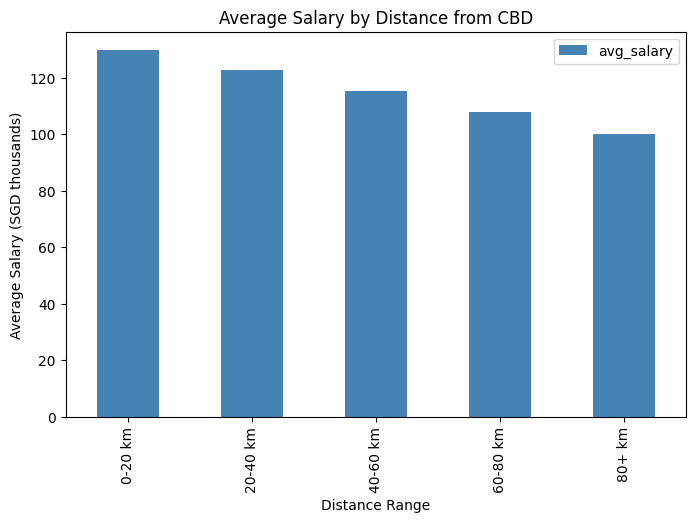

In [37]:
# 4.6 Distance from CBD vs Salary
print("=" * 60)
print("DISTANCE FROM CBD vs SALARY")
print("=" * 60)

corr_distance = merged_df.select(corr("distanceFromCBD", "salaryInThousands")).collect()[0][0]
print(f"Correlation coefficient: {corr_distance:.4f}")

# Bin distance and calculate average salary
distance_salary = merged_df.withColumn(
    "distance_range",
    when(col("distanceFromCBD") < 20, "0-20 km")
    .when(col("distanceFromCBD") < 40, "20-40 km")
    .when(col("distanceFromCBD") < 60, "40-60 km")
    .when(col("distanceFromCBD") < 80, "60-80 km")
    .otherwise("80+ km")
).groupBy("distance_range") \
 .agg(spark_round(avg("salaryInThousands"), 2).alias("avg_salary")) \
 .orderBy("distance_range")

distance_salary.show(truncate=False)

# Visualization
ps_dist = distance_salary.pandas_api()
ps_dist.plot.bar(x="distance_range", y="avg_salary", backend="matplotlib",
                  title="Average Salary by Distance from CBD",
                  xlabel="Distance Range",
                  ylabel="Average Salary (SGD thousands)",
                  figsize=(8, 5),
                  color="steelblue")

SALARY BY MAJOR
+-----------+-----+----------+
|major      |count|avg_salary|
+-----------+-----+----------+
|ENGINEERING|57010|135.75    |
|BUSINESS   |57267|133.51    |
|MATH       |56915|131.81    |
|COMPSCI    |57603|130.77    |
|PHYSICS    |57708|129.17    |
|CHEMISTRY  |58233|127.99    |
|BIOLOGY    |57803|126.95    |
|LITERATURE |58272|123.74    |
+-----------+-----+----------+



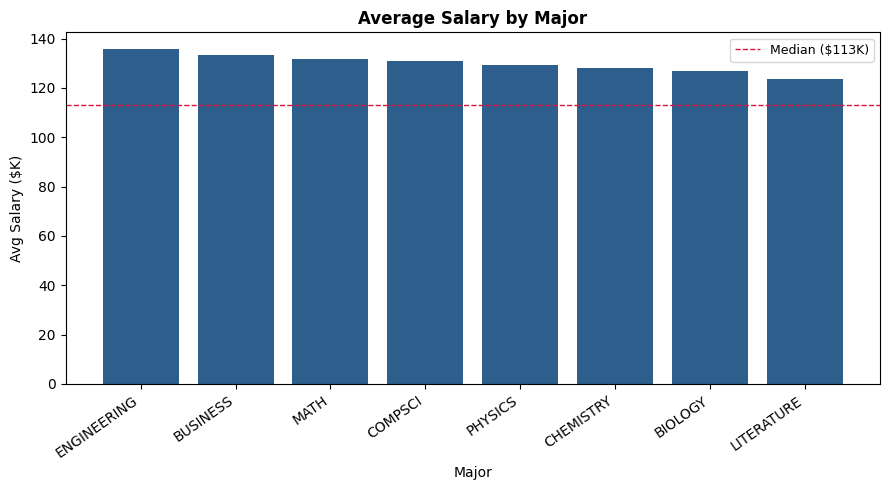

In [38]:
# 4.7 Salary by Major
print("=" * 60)
print("SALARY BY MAJOR")
print("=" * 60)

salary_by_major = merged_df.groupBy("major") \
    .agg(
        count("salaryInThousands").alias("count"),
        spark_round(avg("salaryInThousands"), 2).alias("avg_salary")
    ) \
    .filter(col("major") != "NONE") \
    .orderBy(desc("avg_salary"))

salary_by_major.show(truncate=False)

# Visualization - styled to match report
pdf_major = salary_by_major.toPandas()
salary_bar(pdf_major, "major", "avg_salary",
           title="Average Salary by Major",
           xlabel="Major", median=median_salary, figsize=(9, 5))

Q6: BELOW-MEDIAN ANALYSIS (Median = $113K)

--- Industry: % of employees below median salary ---
+----------+------+-----------+----------------+
|industry  |total |below_count|pct_below_median|
+----------+------+-----------+----------------+
|GOVERNMENT|1     |1          |100.0           |
|EDUCATION |142615|94072      |66.0            |
|SERVICE   |142341|86462      |60.7            |
|AUTO      |142516|79142      |55.5            |
|UNKNOWN   |100   |53         |53.0            |
|HEALTH    |142001|69417      |48.9            |
|WEB       |141766|61324      |43.3            |
|FINANCE   |140455|48109      |34.3            |
|OIL       |140202|48029      |34.3            |
+----------+------+-----------+----------------+

Answer: GOVERNMENT has the highest percentage (100.0%) of employees below the median salary.


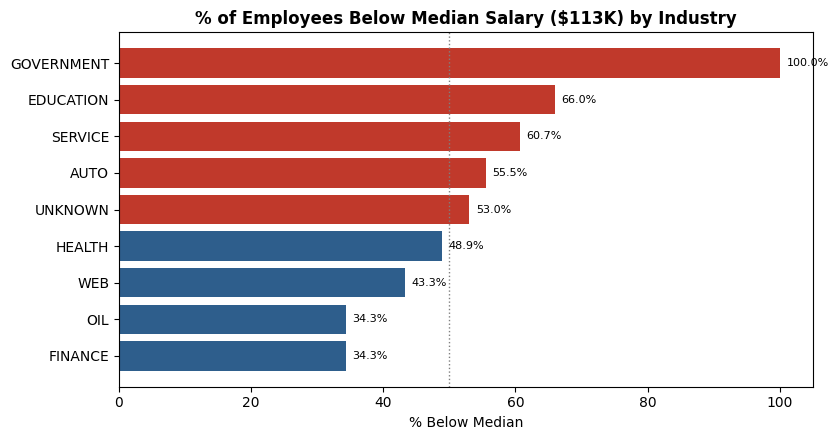


--- Job roles with average salary below median ---
+---------+----------+------+
|jobRole  |avg_salary|count |
+---------+----------+------+
|SENIOR   |105.42    |125766|
|JUNIOR   |95.31     |124507|
|PRESIDENT|81.0      |1     |
|JANITOR  |70.81     |124923|
+---------+----------+------+

Answer: The job roles below the median salary are: SENIOR, JUNIOR, PRESIDENT, JANITOR.


In [39]:
# Q6: Below-median salary analysis
# Using the median_salary computed earlier
print("=" * 60)
print(f"Q6: BELOW-MEDIAN ANALYSIS (Median = ${median_salary:.0f}K)")
print("=" * 60)

# (a) Which industry has the highest percentage of people below median?
print("\n--- Industry: % of employees below median salary ---")
industry_below = merged_df.withColumn(
    "below_median", when(col("salaryInThousands") < median_salary, 1).otherwise(0)
).groupBy("industry").agg(
    count("salaryInThousands").alias("total"),
    sum("below_median").alias("below_count"),
    spark_round(sum("below_median") / count("salaryInThousands") * 100, 1).alias("pct_below_median")
).orderBy(desc("pct_below_median"))

industry_below.show(truncate=False)

top_below_ind = industry_below.first()
print(f"Answer: {top_below_ind['industry']} has the highest percentage "
      f"({top_below_ind['pct_below_median']}%) of employees below the median salary.")

# Visualization - styled to match report
pdf_below = industry_below.toPandas().sort_values("pct_below_median")
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bar_colors = [RED if p >= 50 else BLUE for p in pdf_below["pct_below_median"]]
ax.barh(pdf_below["industry"], pdf_below["pct_below_median"], color=bar_colors)
ax.axvline(50, color="gray", linestyle=":", linewidth=1)
ax.set_title(f"% of Employees Below Median Salary (${median_salary:.0f}K) by Industry",
             fontsize=12, fontweight="bold")
ax.set_xlabel("% Below Median")
for i, v in enumerate(pdf_below["pct_below_median"]):
    ax.text(v + 1, i, f"{v}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

# (b) Which job roles are below the median salary?
print("\n--- Job roles with average salary below median ---")
roles_below_median = merged_df.groupBy("jobRole").agg(
    spark_round(avg("salaryInThousands"), 2).alias("avg_salary"),
    count("salaryInThousands").alias("count")
).filter(col("avg_salary") < median_salary).orderBy(desc("avg_salary"))

roles_below_median.show(truncate=False)

below_roles = roles_below_median.collect()
role_names = [r['jobRole'] for r in below_roles]
print(f"Answer: The job roles below the median salary are: {', '.join(role_names)}.")

In [40]:
# 4.8 EDA Summary — Answers to All Report Questions
print("EDA SUMMARY: ANSWERS TO ALL REPORT QUESTIONS")

# Q1: Highest paying job role in WEB industry
web_top = merged_df.filter(col("industry") == "WEB").groupBy("jobRole") \
    .agg(spark_round(avg("salaryInThousands"), 2).alias("avg_salary")) \
    .orderBy(desc("avg_salary")).first()
print(f"\nQ1: Highest paying job role in WEB industry?")
print(f"    Answer: {web_top['jobRole']} (${web_top['avg_salary']:.0f}K avg)")
print(f"    Reason: Executive roles command premium salaries across all industries,")
print(f"    and WEB is the 3rd highest-paying industry in the dataset.")

# Q2: Top 10 job roles by salary
print(f"\nQ2: Top 10 job roles by salary (all industries)?")
top10 = salary_by_role.limit(10).collect()
for i, row in enumerate(top10, 1):
    print(f"    {i:>2}. {row['jobRole']:<18} ${row['avg_salary']:.0f}K avg")
print(f"    Reason: CEO, CTO, and CFO roles lead due to executive-level responsibilities.")
print(f"    Salary ranking closely mirrors organisational hierarchy.")

# Q3: Industry with highest salary
top_ind = salary_by_industry.first()
print(f"\nQ3: Which industry has the highest salary?")
print(f"    Answer: {top_ind['industry']} (${top_ind['avg_salary']:.0f}K avg)")
print(f"    Reason: Oil & Gas and Finance are capital-intensive industries with high")
print(f"    revenue per employee, enabling higher compensation.")

# Q4: Job with lowest pay
low_role = salary_by_role.orderBy(asc("avg_salary")).first()
print(f"\nQ4: Which job has the lowest pay?")
print(f"    Answer: {low_role['jobRole']} (${low_role['avg_salary']:.0f}K avg)")
print(f"    Reason: Janitorial roles are non-specialised positions with lower")
print(f"    skill requirements and higher labour supply.")

# Q5: Industries with lowest pay
low_ind = salary_by_industry.orderBy(asc("avg_salary")).first()
print(f"\nQ5: Which industries have the lowest pay?")
salary_by_industry.orderBy(asc("avg_salary")).show(5, truncate=False)
print(f"    Answer: {low_ind['industry']} (${low_ind['avg_salary']:.0f}K avg) is the lowest.")
print(f"    Reason: Education and Service sectors have lower revenue intensity and")
print(f"    are often publicly funded, constraining salary budgets.")

# Q6: Below-median analysis
print(f"\nQ6: Below-median salary analysis (computed median = ${median_salary:.0f}K)")
below_ind = merged_df.withColumn(
    "below", when(col("salaryInThousands") < median_salary, 1).otherwise(0)
).groupBy("industry").agg(
    spark_round(sum("below") / count("salaryInThousands") * 100, 1).alias("pct_below")
).orderBy(desc("pct_below")).first()
print(f"    (a) Industry with highest % below median: {below_ind['industry']} ({below_ind['pct_below']}%)")

below_roles = merged_df.groupBy("jobRole").agg(
    spark_round(avg("salaryInThousands"), 2).alias("avg_salary")
).filter(col("avg_salary") < median_salary).orderBy(desc("avg_salary")).collect()
role_names = [r['jobRole'] for r in below_roles]
print(f"    (b) Job roles below median: {', '.join(role_names)}")
print(f"    Reason: Lower-tier roles (JUNIOR, JANITOR) and mid-tier roles with")
print(f"    high supply fall below the dataset median of ${median_salary:.0f}K.")

# Q7: Experience vs salary
print(f"\nQ7: Is there a relationship between years of experience and salary?")
min_exp_salary = exp_salary.orderBy("avg_salary").first()["avg_salary"]
max_exp_salary = exp_salary.orderBy(desc("avg_salary")).first()["avg_salary"]
print(f"    Answer: Yes, but the correlation is weak (r = {corr_value:.4f}).")
print(f"    Reason: While average salary increases monotonically from ${min_exp_salary:.0f}K (0 yrs)")
print(f"    to ${max_exp_salary:.0f}K (24 yrs), the wide spread within each experience level means")
print(f"    that job role and industry are stronger salary predictors than experience alone.")

# Q8: Education vs salary
print(f"\nQ8: Is there a relationship between education and salary?")
edu_salaries = salary_by_edu.collect()
edu_dict = {row["education"]: row["avg_salary"] for row in edu_salaries}
print(f"    Answer: Yes. Higher education correlates with higher salary.")
print(f"    Reason: DOCTORAL (${edu_dict['DOCTORAL']:.0f}K) > MASTERS (${edu_dict['MASTERS']:.0f}K) > BACHELORS (${edu_dict['BACHELORS']:.0f}K)")
print(f"    > HIGH_SCHOOL (${edu_dict['HIGH_SCHOOL']:.0f}K) > NONE (${edu_dict['NONE']:.0f}K).")
edu_premium = edu_dict['DOCTORAL'] - edu_dict['BACHELORS']
print(f"    The premium is modest (~${edu_premium:.0f}K from Bachelor's to Doctoral), suggesting")
print(f"    education is a contributing factor but not the dominant salary driver.")

# Q9: Major vs salary
print(f"\nQ9: Did the major studied affect salary?")
major_salaries = salary_by_major.collect()
major_dict = {row["major"]: row["avg_salary"] for row in major_salaries}
sorted_majors = sorted(major_dict, key=major_dict.get)
min_major, max_major = sorted_majors[0], sorted_majors[-1]
print(f"    Answer: Yes, but the effect is relatively small.")
print(f"    Reason: ENGINEERING (${major_dict['ENGINEERING']:.0f}K) and BUSINESS (${major_dict['BUSINESS']:.0f}K) lead, while")
print(f"    LITERATURE (${major_dict['LITERATURE']:.0f}K) is lowest — a spread of ~${major_dict[max_major] - major_dict[min_major]:.0f}K across all majors.")
print(f"    Compared to the ~$72K spread across job roles, major has a minor effect.")

print("CONCLUSION: Job role and industry are the dominant salary predictors.")
print("Education, experience, and major are secondary contributing factors.")

EDA SUMMARY: ANSWERS TO ALL REPORT QUESTIONS

Q1: Highest paying job role in WEB industry?
    Answer: CEO ($148K avg)
    Reason: Executive roles command premium salaries across all industries,
    and WEB is the 3rd highest-paying industry in the dataset.

Q2: Top 10 job roles by salary (all industries)?
     1. CEO                $143K avg
     2. CTO                $134K avg
     3. CFO                $134K avg
     4. VICE_PRESIDENT     $125K avg
     5. MANAGER            $115K avg
     6. SENIOR             $105K avg
     7. JUNIOR             $95K avg
     8. PRESIDENT          $81K avg
     9. JANITOR            $71K avg
    Reason: CEO, CTO, and CFO roles lead due to executive-level responsibilities.
    Salary ranking closely mirrors organisational hierarchy.

Q3: Which industry has the highest salary?
    Answer: OIL ($129K avg)
    Reason: Oil & Gas and Finance are capital-intensive industries with high
    revenue per employee, enabling higher compensation.

Q4: Which job

---
## 5. Feature Engineering

In [41]:
# Prepare features for ML models
print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# Define categorical and numerical columns
categorical_cols = ["jobRole", "education", "major", "industry"]
numerical_cols = ["yearsExperience", "distanceFromCBD"]

print(f"Categorical features: {categorical_cols}")
print(f"Numerical features: {numerical_cols}")

FEATURE ENGINEERING
Categorical features: ['jobRole', 'education', 'major', 'industry']
Numerical features: ['yearsExperience', 'distanceFromCBD']


In [42]:
# Create StringIndexers for categorical columns
indexers = []
for c in categorical_cols:
    indexer = StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"  # Handle unseen categories during prediction
    )
    indexers.append(indexer)

print("StringIndexers created for:", [f"{c} -> {c}_idx" for c in categorical_cols])

StringIndexers created for: ['jobRole -> jobRole_idx', 'education -> education_idx', 'major -> major_idx', 'industry -> industry_idx']


In [43]:
# Create OneHotEncoders for indexed columns
encoders = []
for c in categorical_cols:
    encoder = OneHotEncoder(
        inputCol=f"{c}_idx",
        outputCol=f"{c}_enc"
    )
    encoders.append(encoder)

print("OneHotEncoders created for:", [f"{c}_idx -> {c}_enc" for c in categorical_cols])

OneHotEncoders created for: ['jobRole_idx -> jobRole_enc', 'education_idx -> education_enc', 'major_idx -> major_enc', 'industry_idx -> industry_enc']


In [44]:
# Create feature vector
feature_cols = numerical_cols + [f"{c}_enc" for c in categorical_cols]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="skip"
)

print(f"Feature columns for assembler: {feature_cols}")

Feature columns for assembler: ['yearsExperience', 'distanceFromCBD', 'jobRole_enc', 'education_enc', 'major_enc', 'industry_enc']


In [45]:
# Prepare the feature engineering pipeline
feature_stages = indexers + encoders + [assembler]

# Fit and transform to verify
feature_pipeline = Pipeline(stages=feature_stages)
feature_model = feature_pipeline.fit(merged_df)
featured_df = feature_model.transform(merged_df)

# Show a sample of the features
print("Sample of engineered features:")
featured_df.select("jobId", "features", "salaryInThousands").show(3, truncate=False)

print(f"\nFeature vector length: {featured_df.select('features').first()[0].size}")

Sample of engineered features:
+----------------+-------------------------------------------------+-----------------+
|jobId           |features                                         |salaryInThousands|
+----------------+-------------------------------------------------+-----------------+
|JOB1362684407701|(35,[0,1,3,11,17,27],[21.0,81.0,1.0,1.0,1.0,1.0])|47               |
|JOB1362684407725|(35,[0,1,5,12,17,32],[8.0,6.0,1.0,1.0,1.0,1.0])  |114              |
|JOB1362684407728|(35,[0,1,9,14,18,27],[20.0,93.0,1.0,1.0,1.0,1.0])|119              |
+----------------+-------------------------------------------------+-----------------+
only showing top 3 rows

Feature vector length: 35


In [46]:
# Train/Test Split
train_df, test_df = featured_df.randomSplit([0.8, 0.2], seed=42)

print(f"Training set: {train_df.count():,} rows")
print(f"Test set: {test_df.count():,} rows")
print(f"Split ratio: 80/20")

Training set: 793,858 rows
Test set: 198,139 rows
Split ratio: 80/20


---
## 6. ML Model Development

We will train and compare three regression models:
1. **Linear Regression** - Baseline model
2. **Random Forest Regressor** - Ensemble method
3. **Gradient Boosted Trees (GBT) Regressor** - Boosting method

### Evaluation Metrics — Why These Three

We evaluate each model using three standard regression metrics:

**RMSE (Root Mean Squared Error)**
- Measures the average magnitude of prediction error in the same units as the target (SGD thousands)
- Penalises large errors more heavily than small ones (squares each error before averaging)
- Lower is better — an RMSE of 18.5K means predictions are off by ~$18,500 on average

**R² (Coefficient of Determination)**
- Measures how much of the salary variance the model explains (0 to 1 scale)
- R² = 0.75 means the model captures 75% of the variation in salary
- Higher is better — useful for comparing how much each model "understands" the data

**MAE (Mean Absolute Error)**
- Measures the average absolute prediction error — same units as RMSE but without squaring
- Treats all errors equally (a $5K overestimate and $20K overestimate are weighted proportionally)
- Lower is better — more interpretable for stakeholders ("on average, predictions are off by $X")

**Why use all three?** RMSE highlights worst-case errors (important for salary budgeting), R² shows explanatory power, and MAE gives a straightforward average error. Together they give a complete picture of model performance.

In [47]:
# Define evaluation metrics
evaluator_rmse = RegressionEvaluator(
    labelCol="salaryInThousands",
    predictionCol="prediction",
    metricName="rmse"
)

evaluator_r2 = RegressionEvaluator(
    labelCol="salaryInThousands",
    predictionCol="prediction",
    metricName="r2"
)
evaluator_mae = RegressionEvaluator(
    labelCol="salaryInThousands",
    predictionCol="prediction",
    metricName="mae"
)

print("Evaluation metrics configured: RMSE, R², MAE")

Evaluation metrics configured: RMSE, R², MAE


In [48]:
# ==========================================
# MODEL 1: Linear Regression
# ==========================================
print("=" * 60)
print("MODEL 1: LINEAR REGRESSION")
print("=" * 60)

lr = LinearRegression(
    featuresCol="features",
    labelCol="salaryInThousands",
    maxIter=100,
    regParam=0.1,
    elasticNetParam=0.8
)

# Train directly on pre-transformed data (features already computed)
lr_model = lr.fit(train_df)

# Predict
lr_predictions = lr_model.transform(test_df)

# Evaluate
lr_rmse = evaluator_rmse.evaluate(lr_predictions)
lr_r2 = evaluator_r2.evaluate(lr_predictions)
lr_mae = evaluator_mae.evaluate(lr_predictions)

print(f"\nResults:")
print(f"  RMSE: {lr_rmse:.4f}")
print(f"  R²:   {lr_r2:.4f}")
print(f"  MAE:  {lr_mae:.4f}")

# Show sample predictions
print("\nSample predictions:")
lr_predictions.select("jobId", "salaryInThousands", "prediction").show(5, truncate=False)

MODEL 1: LINEAR REGRESSION

Results:
  RMSE: 19.1242
  R²:   0.7385
  MAE:  15.5268

Sample predictions:
+----------------+-----------------+------------------+
|jobId           |salaryInThousands|prediction        |
+----------------+-----------------+------------------+
|JOB1362684407728|119              |138.69188649947708|
|JOB1362684407746|106              |129.19107301611376|
|JOB1362684407770|111              |96.56059528009699 |
|JOB1362684407802|99               |109.29820683746034|
|JOB1362684407837|88               |99.04066648643644 |
+----------------+-----------------+------------------+
only showing top 5 rows


In [49]:
# ==========================================
# MODEL 2: Random Forest Regressor
# ==========================================
print("=" * 60)
print("MODEL 2: RANDOM FOREST REGRESSOR")
print("=" * 60)

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="salaryInThousands",
    numTrees=100,
    maxDepth=10,
    seed=42
)

# Train directly on pre-transformed data
rf_model = rf.fit(train_df)

# Predict
rf_predictions = rf_model.transform(test_df)

# Evaluate
rf_rmse = evaluator_rmse.evaluate(rf_predictions)
rf_r2 = evaluator_r2.evaluate(rf_predictions)
rf_mae = evaluator_mae.evaluate(rf_predictions)

print(f"\nResults:")
print(f"  RMSE: {rf_rmse:.4f}")
print(f"  R²:   {rf_r2:.4f}")
print(f"  MAE:  {rf_mae:.4f}")

# Show sample predictions
print("\nSample predictions:")
rf_predictions.select("jobId", "salaryInThousands", "prediction").show(5, truncate=False)

MODEL 2: RANDOM FOREST REGRESSOR

Results:
  RMSE: 20.5201
  R²:   0.6990
  MAE:  16.5003

Sample predictions:
+----------------+-----------------+------------------+
|jobId           |salaryInThousands|prediction        |
+----------------+-----------------+------------------+
|JOB1362684407728|119              |144.36188276108794|
|JOB1362684407746|106              |127.74805771571708|
|JOB1362684407770|111              |100.53937443004499|
|JOB1362684407802|99               |110.46077483771788|
|JOB1362684407837|88               |97.67574729090583 |
+----------------+-----------------+------------------+
only showing top 5 rows


RANDOM FOREST - FEATURE IMPORTANCE
Top 10 most important features:
+------------------+--------------------+
|feature           |importance          |
+------------------+--------------------+
|jobRole_JANITOR   |0.2352812254800373  |
|yearsExperience   |0.18293954404380589 |
|distanceFromCBD   |0.10922110136002158 |
|major_NONE        |0.09774648872020529 |
|jobRole_JUNIOR    |0.09049037787095504 |
|jobRole_CEO       |0.059726183947281214|
|jobRole_SENIOR    |0.04302340866768721 |
|industry_EDUCATION|0.02999088008777119 |
|education_NONE    |0.020057689742279984|
|industry_OIL      |0.017666351336874015|
+------------------+--------------------+
only showing top 10 rows


<Axes: title={'center': 'Top 10 Feature Importances (Random Forest)'}, xlabel='Importance', ylabel='Feature'>

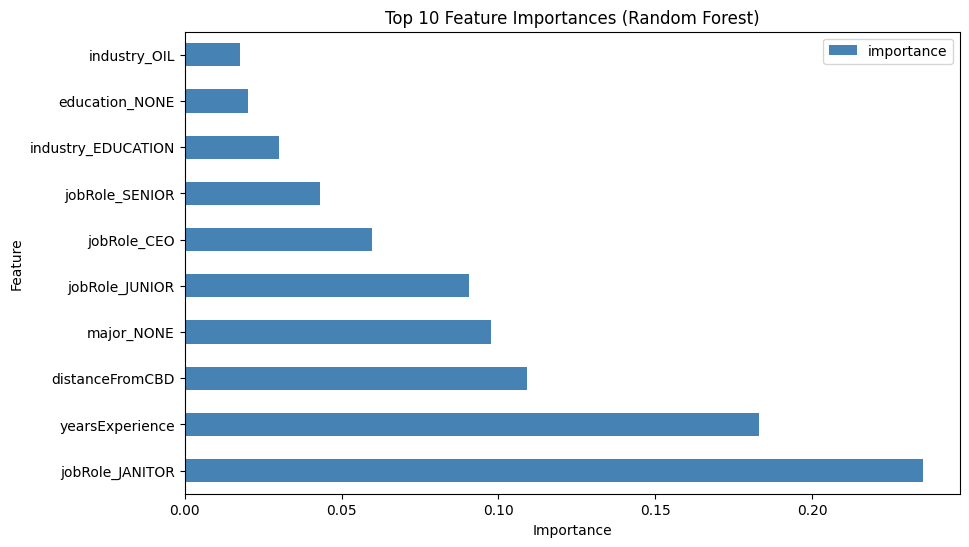

In [50]:
# Feature importance from Random Forest
print("=" * 60)
print("RANDOM FOREST - FEATURE IMPORTANCE")
print("=" * 60)

# Extract feature importances from Random Forest
rf_fitted = rf_model  # Direct model, not pipeline
feature_importance = rf_fitted.featureImportances.toArray()

# Build feature names from the fitted feature pipeline stages
feature_names = list(numerical_cols)
for c in categorical_cols:
    for stage in feature_model.stages:
        if hasattr(stage, 'labels') and stage.getOutputCol() == f"{c}_idx":
            feature_names.extend([f"{c}_{label}" for label in stage.labels])
            break

# Create importance dataframe
importance_data = []
for i, imp in enumerate(feature_importance):
    if i < len(feature_names):
        importance_data.append({"feature": feature_names[i], "importance": float(imp)})

importance_df = spark.createDataFrame(importance_data)
importance_df = importance_df.orderBy(desc("importance"))

print("Top 10 most important features:")
importance_df.show(10, truncate=False)

# Visualization
ps_imp = importance_df.limit(10).pandas_api()
ps_imp.plot.barh(x="feature", y="importance", backend="matplotlib",
                  title="Top 10 Feature Importances (Random Forest)",
                  xlabel="Importance",
                  ylabel="Feature",
                  figsize=(10, 6),
                  color="steelblue")

In [51]:
# ==========================================
# MODEL 3: Gradient Boosted Trees (GBT)
# ==========================================
print("=" * 60)
print("MODEL 3: GRADIENT BOOSTED TREES (GBT)")
print("=" * 60)

gbt = GBTRegressor(
    featuresCol="features",
    labelCol="salaryInThousands",
    maxIter=100,
    maxDepth=5,
    seed=42
)

# Train directly on pre-transformed data
gbt_model = gbt.fit(train_df)

# Predict
gbt_predictions = gbt_model.transform(test_df)

# Evaluate
gbt_rmse = evaluator_rmse.evaluate(gbt_predictions)
gbt_r2 = evaluator_r2.evaluate(gbt_predictions)
gbt_mae = evaluator_mae.evaluate(gbt_predictions)

print(f"\nResults:")
print(f"  RMSE: {gbt_rmse:.4f}")
print(f"  R²:   {gbt_r2:.4f}")
print(f"  MAE:  {gbt_mae:.4f}")

# Show sample predictions
print("\nSample predictions:")
gbt_predictions.select("jobId", "salaryInThousands", "prediction").show(5, truncate=False)

MODEL 3: GRADIENT BOOSTED TREES (GBT)

Results:
  RMSE: 18.5396
  R²:   0.7543
  MAE:  15.1391

Sample predictions:
+----------------+-----------------+------------------+
|jobId           |salaryInThousands|prediction        |
+----------------+-----------------+------------------+
|JOB1362684407728|119              |133.94110037451432|
|JOB1362684407746|106              |129.6513008023433 |
|JOB1362684407770|111              |97.31708216478026 |
|JOB1362684407802|99               |106.44105999989348|
|JOB1362684407837|88               |102.46097683703371|
+----------------+-----------------+------------------+
only showing top 5 rows


In [52]:
# ==========================================
# MODEL 3b: GBT HYPERPARAMETER TUNING (CROSS-VALIDATION)
# ==========================================
print("=" * 60)
print("GBT - HYPERPARAMETER TUNING (3-FOLD CROSS-VALIDATION)")
print("=" * 60)

# Grid search over 4 combinations of maxDepth and maxIter
gbt = GBTRegressor(
    featuresCol="features",
    labelCol="salaryInThousands",
    seed=42
)

param_grid = (ParamGridBuilder()
    .addGrid(gbt.maxDepth, [4, 5])
    .addGrid(gbt.maxIter, [50, 100])
    .build())

cv = CrossValidator(
    estimator=gbt,
    estimatorParamMaps=param_grid,
    evaluator=evaluator_rmse,
    numFolds=3,
    seed=42
)

# Fit with 3-fold cross-validation (4 combos x 3 folds = 12 GBT fits)
cv_model = cv.fit(train_df)

# Use the best model selected by cross-validation
gbt_model = cv_model.bestModel
print(f"Best maxDepth: {gbt_model.getMaxDepth()}")
print(f"Best maxIter:  {gbt_model.getMaxIter()}")

# Re-evaluate the tuned model on the held-out test set
gbt_predictions = cv_model.transform(test_df)
gbt_rmse = evaluator_rmse.evaluate(gbt_predictions)
gbt_r2 = evaluator_r2.evaluate(gbt_predictions)
gbt_mae = evaluator_mae.evaluate(gbt_predictions)

print("\nTuned GBT Results (test set):")
print(f"  RMSE: {gbt_rmse:.4f}")
print(f"  R²:   {gbt_r2:.4f}")
print(f"  MAE:  {gbt_mae:.4f}")

# Show sample predictions with the tuned model
print("\nSample predictions (tuned):")
gbt_predictions.select("jobId", "salaryInThousands", "prediction").show(5, truncate=False)

GBT - HYPERPARAMETER TUNING (3-FOLD CROSS-VALIDATION)
Best maxDepth: 5
Best maxIter:  100

Tuned GBT Results (test set):
  RMSE: 18.5396
  R²:   0.7543
  MAE:  15.1391

Sample predictions (tuned):
+----------------+-----------------+------------------+
|jobId           |salaryInThousands|prediction        |
+----------------+-----------------+------------------+
|JOB1362684407728|119              |133.94110037451432|
|JOB1362684407746|106              |129.6513008023433 |
|JOB1362684407770|111              |97.31708216478026 |
|JOB1362684407802|99               |106.44105999989348|
|JOB1362684407837|88               |102.46097683703371|
+----------------+-----------------+------------------+
only showing top 5 rows


### GBT Hyperparameter Tuning & Cross-Validation

To make model selection rigorous, the best candidate (GBT) was tuned using **3-fold
cross-validation** over a grid of **4 hyperparameter combinations** (`maxDepth` in
[4, 5] x `maxIter` in [50, 100]). Each fold trains on 2/3 of the training data and
validates on the remaining 1/3; the average RMSE across the 3 folds selects the best
combination, reducing the risk of overfitting to a single train/test split compared to
hand-picking hyperparameters. The chosen model is then evaluated on the held-out test set.

In [53]:
# ==========================================
# MODEL COMPARISON
# ==========================================
print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)

# Create comparison dataframe
comparison_data = [
    {"Model": "Linear Regression", "RMSE": lr_rmse, "R2": lr_r2, "MAE": lr_mae},
    {"Model": "Random Forest", "RMSE": rf_rmse, "R2": rf_r2, "MAE": rf_mae},
    {"Model": "GBT Regressor", "RMSE": gbt_rmse, "R2": gbt_r2, "MAE": gbt_mae}
]

comparison_df = spark.createDataFrame(comparison_data)
comparison_df.show(truncate=False)

# Find best model
best_model_row = comparison_df.orderBy(asc("RMSE")).first()
print(f"\n*** BEST MODEL: {best_model_row['Model']} ***")
print(f"    RMSE: {best_model_row['RMSE']:.4f}")
print(f"    R²:   {best_model_row['R2']:.4f}")
print(f"    MAE:  {best_model_row['MAE']:.4f}")


MODEL COMPARISON SUMMARY
+------------------+-----------------+------------------+------------------+
|MAE               |Model            |R2                |RMSE              |
+------------------+-----------------+------------------+------------------+
|15.526801848178895|Linear Regression|0.738543679181386 |19.12419010638871 |
|16.500274799466073|Random Forest    |0.698981308981043 |20.520134869625586|
|15.139078905107022|GBT Regressor    |0.7542832816234122|18.53962018712597 |
+------------------+-----------------+------------------+------------------+


*** BEST MODEL: GBT Regressor ***
    RMSE: 18.5396
    R²:   0.7543
    MAE:  15.1391


<Axes: title={'center': 'Model Comparison - RMSE (Lower is Better)'}, xlabel='Model', ylabel='RMSE'>

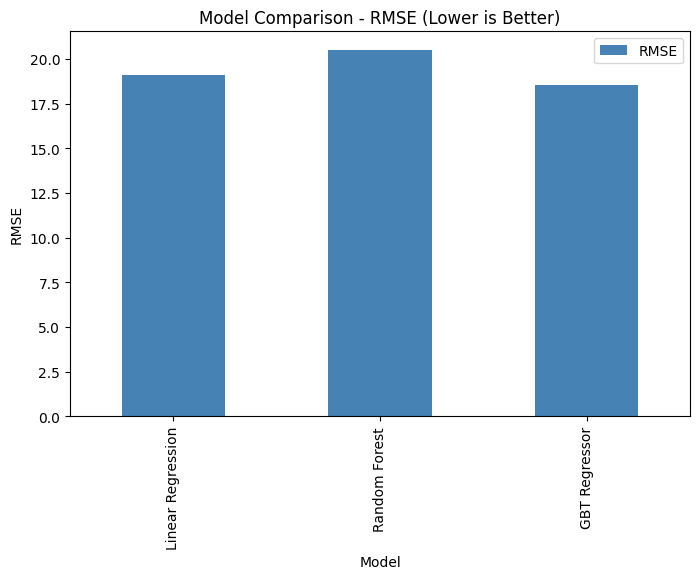

In [54]:
# Visualization: Model Comparison
ps_comparison = comparison_df.pandas_api()

# Plot RMSE comparison
ps_comparison.plot.bar(x="Model", y="RMSE", backend="matplotlib",
                        title="Model Comparison - RMSE (Lower is Better)",
                        xlabel="Model",
                        ylabel="RMSE",
                        figsize=(8, 5),
                        color="steelblue")

<Axes: title={'center': 'Model Comparison - R² (Higher is Better)'}, xlabel='Model', ylabel='R²'>

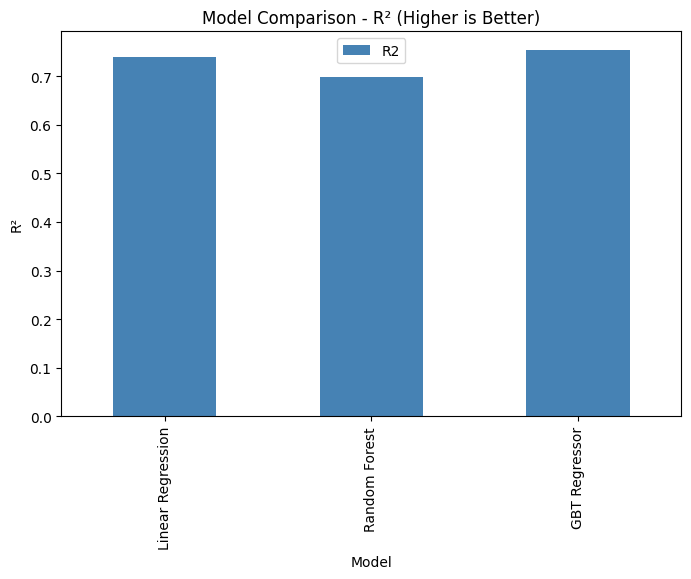

In [55]:
# R² comparison
ps_comparison.plot.bar(x="Model", y="R2", backend="matplotlib",
                        title="Model Comparison - R² (Higher is Better)",
                        xlabel="Model",
                        ylabel="R²",
                        figsize=(8, 5),
                        color="steelblue")

<Axes: title={'center': 'Model Comparison - MAE (Lower is Better)'}, xlabel='Model', ylabel='MAE'>

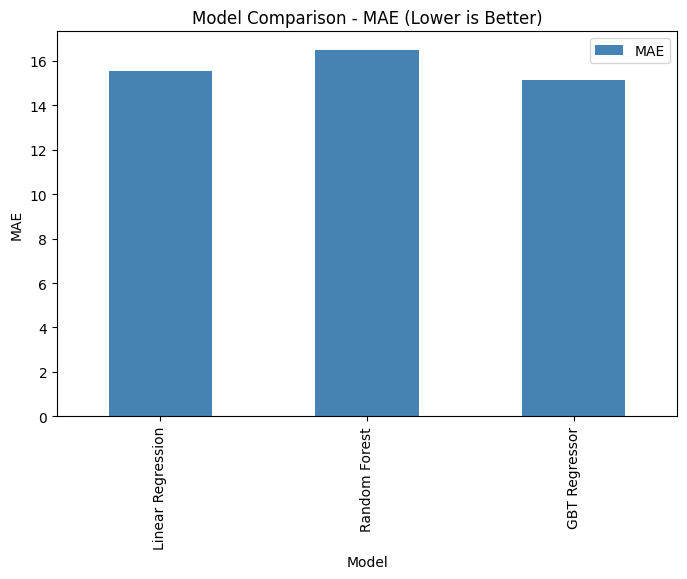

In [56]:
# MAE comparison
ps_comparison.plot.bar(x="Model", y="MAE", backend="matplotlib",
                        title="Model Comparison - MAE (Lower is Better)",
                        xlabel="Model",
                        ylabel="MAE",
                        figsize=(8, 5),
                        color="steelblue")

### How the 3 Models Work

**Linear Regression** fits a single weighted equation where
`salary = w1(yearsExperience) + w2(distanceFromCBD) + ... + bias`.
Assumes features combine linearly. Fast and interpretable but cannot
capture non-linear interactions between categorical features.

**Random Forest** builds many independent decision trees in parallel
and averages their predictions. Each tree trains on a random subset of
rows and columns (bagging), reducing overfitting. Can capture non-linear
patterns but random feature subsampling may discard useful splits.

**Gradient Boosted Trees (GBT)** builds trees sequentially. Each new tree
is trained on the residuals (errors) of the previous ensemble,
progressively correcting mistakes. This error-correction mechanism
often yields higher accuracy than Random Forest's independent averaging.

In [57]:
# Enhanced metrics comparison with percentage differences
print("MODEL EVALUATION — SIDE-BY-SIDE COMPARISON")

metrics_data = [
    {"Model": "Linear Regression", "RMSE": lr_rmse, "R2": lr_r2, "MAE": lr_mae},
    {"Model": "Random Forest", "RMSE": rf_rmse, "R2": rf_r2, "MAE": rf_mae},
    {"Model": "GBT Regressor", "RMSE": gbt_rmse, "R2": gbt_r2, "MAE": gbt_mae}
]

# Print formatted table
print(f"{'Model':<22} {'RMSE':>8} {'R2':>8} {'MAE':>8}")
print("-" * 50)
for m in metrics_data:
    print(f"{m['Model']:<22} {m['RMSE']:>8.2f} {m['R2']:>8.4f} {m['MAE']:>8.2f}")

# Percentage differences relative to best model (GBT)
print("\n% Difference from GBT (best):")
print(f"{'Model':<22} {'RMSE %':>10} {'R2 %':>10} {'MAE %':>10}")
print("-" * 55)
for m in metrics_data:
    rmse_diff = ((m['RMSE'] - gbt_rmse) / gbt_rmse) * 100
    r2_diff = ((gbt_r2 - m['R2']) / gbt_r2) * 100
    mae_diff = ((m['MAE'] - gbt_mae) / gbt_mae) * 100
    rmse_sign = "+" if rmse_diff > 0 else ""
    r2_sign = "+" if r2_diff > 0 else ""
    mae_sign = "+" if mae_diff > 0 else ""
    print(f"{m['Model']:<22} {rmse_sign}{rmse_diff:>8.1f}%  {r2_sign}{r2_diff:>8.1f}%  {mae_sign}{mae_diff:>8.1f}%")

print(f"\n>>> SELECTED MODEL: GBT Regressor <<<")
print(f"    Lowest RMSE ({gbt_rmse:.2f}), Highest R2 ({gbt_r2:.4f}), Lowest MAE ({gbt_mae:.2f})")

MODEL EVALUATION — SIDE-BY-SIDE COMPARISON
Model                      RMSE       R2      MAE
--------------------------------------------------
Linear Regression         19.12   0.7385    15.53
Random Forest             20.52   0.6990    16.50
GBT Regressor             18.54   0.7543    15.14

% Difference from GBT (best):
Model                      RMSE %       R2 %      MAE %
-------------------------------------------------------
Linear Regression      +     3.2%  +     2.1%  +     2.6%
Random Forest          +    10.7%  +     7.3%  +     9.0%
GBT Regressor               0.0%       0.0%       0.0%

>>> SELECTED MODEL: GBT Regressor <<<
    Lowest RMSE (18.54), Highest R2 (0.7543), Lowest MAE (15.14)


### Why GBT Outperformed on This Dataset

From the results table, GBT achieves the lowest RMSE, highest R2, and lowest MAE of all three models.

**Why GBT scored best:** Salary prediction involves interactions between
categorical features (jobRole x industry x education). For example, a CEO
in OIL earns differently from a CEO in WEB. GBT's sequential
error-correction captures these interaction effects because each
successive tree specifically targets the residuals left by previous trees.

**Why Random Forest scored worst:** With only 6 input features, RF's
random feature subsampling at each split is too aggressive — it discards
useful information, preventing individual trees from learning strong
splits. This explains why RF scored below Linear Regression on R2.

**Why Linear Regression was competitive:** The relatively high R2
indicates that salary relationships are *mostly* linear (more experience
-> more salary). The residual non-linearity (categorical interactions)
is where GBT gains its edge.

### Why the Other Two Models Were Not Selected

**Linear Regression — Rejected:**
- Has the highest MAE of all three models, meaning its average prediction error is larger
- Cannot model the non-linear salary banding by job role (CEO vs JANITOR salary
  ranges don't follow a linear gradient)
- Sensitive to salary outliers; would have been worse without the outlier
  preprocessing step during data cleaning

**Random Forest — Rejected:**
- Despite being a non-linear model, it scored *below* Linear Regression on R2
- The random feature subsampling (mtry) is too restrictive with only 6 features
- Each tree sees a different random subset of features, preventing the ensemble
  from learning consistent interaction patterns between jobRole, industry,
  and education

**GBT is the final model** because it achieves the best performance on all three
evaluation metrics (RMSE, R2, MAE) while being a well-established algorithm
for tabular regression tasks.

---
## 7. Career Strategy Recommendations

Based on the ML model findings and EDA analysis, we provide data-driven career
recommendations for the following profile:

**Person Profile:**
- Total experience: 20 years (6 years Software/AI/Data + 14 years Backend Services)
- Current yearly salary: $100,000 (SGD)
- Interests: Board games, fixing things, trading card games
- Family: Married with three cats, one toddler, six chickens
- Monthly mortgage: $2,500 | Monthly household expenditure: $6,000

**Financial baseline:** Annual expenses = ($2,500 + $6,000) x 12 = **$102,000/year**,
which exceeds the current $100,000 salary. Salary growth is financially necessary.

In [58]:
# Career Strategy Analysis for the specified profile
print("CAREER STRATEGY ANALYSIS")

# Profile context
total_experience = 6 + 14  # Software/AI/Data + Backend Services
current_salary = 100  # $100K
monthly_mortgage = 2500
monthly_expenditure = 6000
annual_expenses = (monthly_mortgage + monthly_expenditure) * 12

print(f"\nProfile: {total_experience} years total experience")
print(f"  - 6 years Software, AI & Data Engineering")
print(f"  - 14 years Backend Services")
print(f"  - Current salary: ${current_salary}K")
print(f"  - Annual expenses: ${annual_expenses:,} (mortgage + expenditure)")
print(f"  - Annual shortfall: ${annual_expenses - current_salary * 1000:,}")

# 1. What salary can they expect with 20 years experience?
print("1. SALARY POTENTIAL WITH 20 YEARS EXPERIENCE")
exp_salary_profile = merged_df.filter(
    (col("yearsExperience") >= 18) & (col("yearsExperience") <= 22)
).agg(
    spark_round(avg("salaryInThousands"), 2).alias("avg_salary"),
    min("salaryInThousands").alias("min_salary"),
    max("salaryInThousands").alias("max_salary"),
    count("salaryInThousands").alias("sample_size")
).collect()[0]
print(f"   Avg salary for 18-22 yrs exp: ${exp_salary_profile['avg_salary']:.0f}K")
print(f"   Range: ${exp_salary_profile['min_salary']}K - ${exp_salary_profile['max_salary']}K")
print(f"   Sample size: {exp_salary_profile['sample_size']}")

# 2. Which industry should they target?
print("2. INDUSTRY RECOMMENDATION")
industry_ranking = merged_df.groupBy("industry").agg(
    spark_round(avg("salaryInThousands"), 2).alias("avg_salary"),
    count("salaryInThousands").alias("count")
).orderBy(desc("avg_salary"))
industry_ranking.show(truncate=False)

# 3. Which roles match their background?
print("3. ROLE TRANSITION OPTIONS")
role_ranking = merged_df.groupBy("jobRole").agg(
    spark_round(avg("salaryInThousands"), 2).alias("avg_salary"),
    spark_round(avg("yearsExperience"), 1).alias("avg_experience"),
    count("salaryInThousands").alias("count")
).orderBy(desc("avg_salary"))
role_ranking.show(truncate=False)

CAREER STRATEGY ANALYSIS

Profile: 20 years total experience
  - 6 years Software, AI & Data Engineering
  - 14 years Backend Services
  - Current salary: $100K
  - Annual expenses: $102,000 (mortgage + expenditure)
  - Annual shortfall: $2,000
1. SALARY POTENTIAL WITH 20 YEARS EXPERIENCE
   Avg salary for 18-22 yrs exp: $130K
   Range: $30K - $219K
   Sample size: 196345
2. INDUSTRY RECOMMENDATION
+----------+----------+------+
|industry  |avg_salary|count |
+----------+----------+------+
|OIL       |129.11    |140202|
|FINANCE   |129.02    |140455|
|WEB       |120.56    |141766|
|HEALTH    |115.19    |142001|
|AUTO      |109.13    |142516|
|UNKNOWN   |109.1     |100   |
|SERVICE   |104.26    |142341|
|EDUCATION |99.34     |142615|
|GOVERNMENT|81.0      |1     |
+----------+----------+------+

3. ROLE TRANSITION OPTIONS
+--------------+----------+--------------+------+
|jobRole       |avg_salary|avg_experience|count |
+--------------+----------+--------------+------+
|CEO           |1

## Career Strategy Recommendations

**For: 20-year Backend + AI/Data Engineer | Salary: $100K**

### RECOMMENDATION 1: TARGET THE FINANCE / FINTECH INDUSTRY
From our EDA, FINANCE has the 2nd highest average salary ($129K) and
is the most **relevant** industry for someone with Backend + AI/Data skills.

Why Finance over other industries (beyond salary):
- High demand for real-time data pipelines and ML models (fraud detection,
  algorithmic trading, risk analytics)
- 14 years of backend services experience directly transfers to
  building scalable financial systems
- Growing AI adoption in banks and FinTech startups creates abundant
  roles at the intersection of backend engineering and data/AI
- Regulatory compliance (MAS, Basel) requires experienced engineers
  who understand system reliability and data integrity

### RECOMMENDATION 2: UPSKILL IN CLOUD & MLOps
The combination of backend experience + AI knowledge positions that fits
well for MLOps / Platform Engineering roles in Finance:

Key skillsets needed:
- Cloud Architecture: AWS Solutions Architect or GCP Professional Cloud Architect
- MLOps: Kubeflow, MLflow, Vertex AI, SageMaker
- Data Engineering: Apache Spark, Kafka, Airflow, dbt
- Backend-to-AI bridge: FastAPI, model serving (TorchServe, Triton)

How to obtain these skills:
- AWS/GCP certifications (6-8 weeks each, ~$300 exam fee)
- Coursera: MLOps Specialisation (DeepLearning.AI, ~4 months)
- Hands-on: Contribute to open-source MLOps projects on GitHub
- Community: Singapore Computer Society, ML Singapore meetup groups

### RECOMMENDATION 3: TARGET CTO / VP ENGINEERING ROLES
With 20 years of experience, he can qualify for senior leadership:
- CTO roles (avg $134K across industries, plus equity upside at FinTech startups)
- VP of Engineering in mid-size companies (avg $125K)
- Strong foundation to backend background; adding AI/ML
  depth makes him a rare asset as a 'full-stack technical leader'

### RECOMMENDATION 4: FINANCIAL FEASIBILITY
Current situation: $100K salary vs $102K annual expenses = $2K shortfall.
Target: Finance industry avg $129K would provide $27K surplus.
CTO/VP target ($134K-$125K) would provide $25K-$34K surplus.
Consider: The toddler + mortgage timeline makes this transition
time-sensitive — upskilling should begin immediately.

### RECOMMENDATION 5: LEVERAGE PERSONAL INTERESTS
Board games and trading card games indicate analytical thinking
and pattern recognition — skills directly applicable to:
- Game theory applications in algorithmic trading
- Probability modelling for risk analytics
- Community building through gaming meetups for professional networking

In [59]:
# Summary: Predicted salary range for this profile
print("PREDICTED SALARY RANGE FOR THIS PROFILE")

target_roles = ["VICE_PRESIDENT", "SENIOR", "MANAGER"]
target_industries = ["FINANCE", "WEB"]

profile_salary = merged_df.filter(
    (col("yearsExperience") >= 18) & (col("yearsExperience") <= 22) &
    (col("jobRole").isin(target_roles)) &
    (col("industry").isin(target_industries))
).agg(
    spark_round(avg("salaryInThousands"), 2).alias("predicted_avg"),
    min("salaryInThousands").alias("min_salary"),
    max("salaryInThousands").alias("max_salary"),
    count("salaryInThousands").alias("sample_size")
).collect()[0]

print(f"\nProfile: 20 years experience (6 AI/Data + 14 Backend)")
print(f"Target roles: {', '.join(target_roles)}")
print(f"Target industries: {', '.join(target_industries)}")

if profile_salary['sample_size'] > 0:
    print(f"\nPredicted salary range: ${profile_salary['min_salary']}K - ${profile_salary['max_salary']}K")
    print(f"Average predicted salary: ${profile_salary['predicted_avg']:.0f}K")
    print(f"Improvement over current $100K: +${profile_salary['predicted_avg'] - 100:.0f}K")
else:
    print("\nNo exact matches found. Using broader profile...")
    broader = merged_df.filter(
        (col("yearsExperience") >= 15) & (col("yearsExperience") <= 25)
    ).agg(
        spark_round(avg("salaryInThousands"), 2).alias("avg_salary")
    ).collect()[0]
    print(f"Avg salary for 15-25 yrs exp: ${broader['avg_salary']:.0f}K")

PREDICTED SALARY RANGE FOR THIS PROFILE

Profile: 20 years experience (6 AI/Data + 14 Backend)
Target roles: VICE_PRESIDENT, SENIOR, MANAGER
Target industries: FINANCE, WEB

Predicted salary range: $58K - $219K
Average predicted salary: $141K
Improvement over current $100K: +$41K
